In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import scipy.stats as stats
import statsmodels.api as sm
from scipy.special import gamma
from scipy.optimize import minimize_scalar
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.signal import welch

In [166]:
discounts  = pd.read_excel('discounts.xlsx', index_col='date').dropna()
panel_data  = pd.read_excel('macrodata.xlsx').dropna()

In [167]:
meeting_cal = pd.DatetimeIndex(panel_data["meeting_date"].dropna().unique()).sort_values()
tenors = np.array(discounts.columns.to_list(), dtype=float)
curves = {d: Curve(tenors, discounts.loc[d].values) for d in discounts.index}

In [168]:
starts = np.zeros(tenors.shape[0]-1)
starts = tenors[:-1]
ends = np.zeros(tenors.shape[0]-1)
ends = tenors[1:]

fwds =  pd.DataFrame(index=discounts.index, columns=tenors[1:])
for date, curve in curves.items():
    fwds.loc[date] = [curve.fwd_rate(s, e) for s, e in zip(starts, ends)]

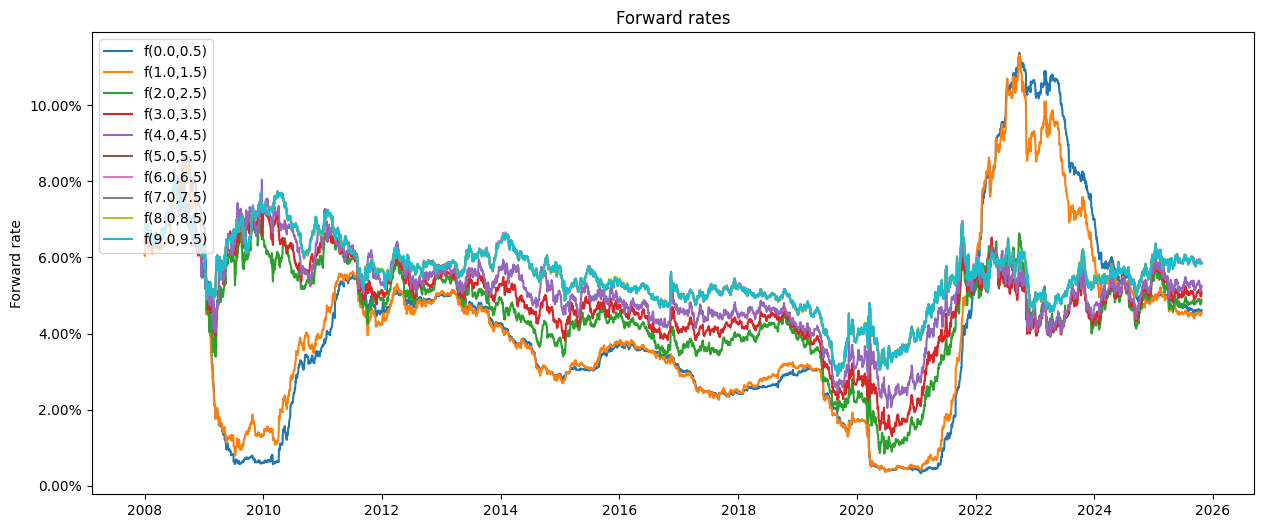

In [169]:
fig, ax = plt.subplots(figsize=(15,6))
for i, (h, s, e) in enumerate(zip(fwds.columns, starts, ends)):
    if i % 2 == 0:
        ax.plot(fwds.index, fwds[h], label=f"f({s.round(2)},{e.round(2)})")

ax.set_title("Forward rates")
ax.set_ylabel("Forward rate")
ax.yaxis.set_major_formatter('{x:.2%}')
ax.legend(loc='upper left')
plt.show()

In [170]:
fwds

,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,9.5,10.0
date,,,,,,,,,,,,,,,,,,,,
2008-01-02,0.061225,0.059313,0.060515,0.074162,0.064173,0.065236,0.064463,0.065531,0.065118,0.065833,0.067259,0.068374,0.067259,0.068374,0.067259,0.068374,0.06763,0.068374,0.067259,0.068374
2008-01-03,0.061176,0.059137,0.0604,0.074942,0.063294,0.064343,0.064303,0.065369,0.065482,0.066202,0.066803,0.06791,0.066803,0.06791,0.066803,0.06791,0.067172,0.06791,0.066803,0.06791
2008-01-04,0.062322,0.060201,0.061524,0.078113,0.065169,0.066249,0.066008,0.067102,0.0666,0.067331,0.067093,0.068205,0.067093,0.068205,0.067093,0.068205,0.067464,0.068205,0.067093,0.068205
2008-01-07,0.063191,0.061851,0.062806,0.081642,0.066267,0.067365,0.066306,0.067405,0.067923,0.068669,0.068654,0.069791,0.068654,0.069791,0.068654,0.069791,0.069033,0.069791,0.068654,0.069791
2008-01-08,0.06442,0.062062,0.063537,0.08057,0.067554,0.068674,0.06774,0.068863,0.069867,0.070635,0.068922,0.070064,0.068922,0.070064,0.068922,0.070064,0.069302,0.070064,0.068922,0.070064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-17,0.045914,0.04326,0.044967,0.047491,0.047895,0.047895,0.049708,0.049981,0.051578,0.051862,0.0583,0.05862,0.05862,0.05862,0.0583,0.05862,0.0583,0.05862,0.0583,0.05862
2025-10-20,0.045966,0.04358,0.045156,0.04795,0.048145,0.048145,0.049963,0.050237,0.051269,0.051551,0.058384,0.058705,0.058705,0.058705,0.058384,0.058705,0.058384,0.058705,0.058384,0.058705
2025-10-21,0.046062,0.043577,0.045203,0.048427,0.047972,0.047972,0.050024,0.050298,0.051597,0.051881,0.058458,0.05878,0.05878,0.05878,0.058458,0.05878,0.058458,0.05878,0.058458,0.05878


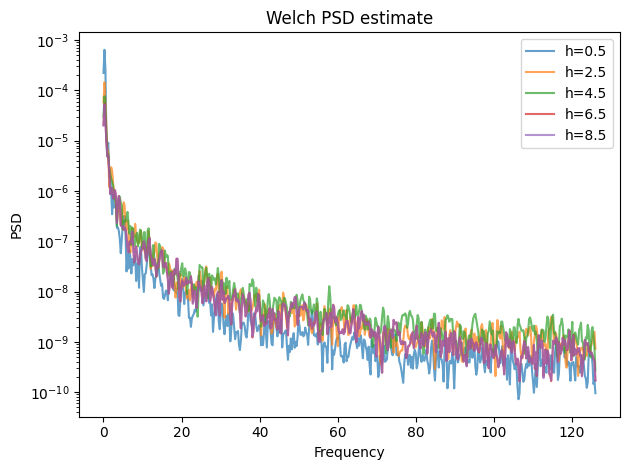

In [171]:
plt.figure()
for i, h in enumerate(fwds.columns):
    if i % 4 == 0:        
        x = fwds[h].dropna().to_numpy().astype(float)
        f, Pxx = welch(x, fs=252.0, nperseg=1024, detrend="linear")
        plt.semilogy(f, Pxx, label="h="+str(h), alpha=0.7)
plt.xlabel("Frequency")
plt.ylabel("PSD")
plt.title("Welch PSD estimate")
plt.legend()
plt.tight_layout()
plt.show()

In [172]:
def fracdiff_weights(d: float, n: int) -> np.ndarray:
    """
    Compute weights pi_k(d) for k=0..n-1 in (1-L)^d expansion using stable recursion:
      pi_0 = 1
      pi_k = pi_{k-1} * (k-1-d)/k
    """
    w = np.empty(n, dtype=float)
    w[0] = 1.0
    for k in range(1, n):
        w[k] = w[k-1] * ((k - 1 - d) / k)
    return w

def fracdiff(y: np.ndarray, d: float, trim: int | None = None) -> np.ndarray:
    """
    Fractionally difference y with order d: x_t = sum_{k=0}^{t} pi_k(d) y_{t-k}.
    For finite samples, we truncate at available history.

    trim: number of initial observations to drop to reduce startup effects.
          If None, we keep all.
    """
    y = np.asarray(y, dtype=float)
    n = y.size
    w = fracdiff_weights(d, n)
    x = np.zeros(n, dtype=float)

    # convolution-like computation with triangular truncation
    for t in range(n):
        kmax = t + 1
        x[t] = np.dot(w[:kmax], y[t::-1])

    if trim is None or trim <= 0:
        return x
    return x[trim:]

def _ols_tstat(y: np.ndarray, X: np.ndarray, idx_param: int) -> tuple[float, float, np.ndarray]:
    """
    OLS with homoskedastic SE; returns (beta_hat[idx], t_stat[idx], residuals).
    """
    y = y.reshape(-1, 1)
    X = np.asarray(X, dtype=float)
    n, k = X.shape

    # beta = (X'X)^{-1} X'y
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    beta = XtX_inv @ (X.T @ y)  # (k,1)
    resid = (y - X @ beta).ravel()

    s2 = (resid @ resid) / (n - k)
    var_beta = s2 * XtX_inv
    se = np.sqrt(np.diag(var_beta))

    tstats = (beta.ravel() / se)
    return beta.ravel()[idx_param], tstats[idx_param], resid

def fadf_test(
    y: np.ndarray,
    d0: float = 1.0,
    d1: float = 0.0,
    lags: int = 0,
    add_const: bool = False,
    trim: int | None = None,
    bootstrap: int = 0,
    seed: int | None = None
) -> dict:
    """
    Fractional (Augmented) Dickey–Fuller style test in the DGM spirit:
      Δ^{d0} y_t = ρ Δ^{d1} y_{t-1} + Σ_{i=1}^lags φ_i Δ^{d0} y_{t-i} + (const) + ε_t

    Null is typically ρ = 0; one-sided alternative ρ < 0 (reject for very negative t).

    Returns a dict with t_stat, normal_approx_pvalue (one-sided), and optional bootstrap p-value.
    """
    y = np.asarray(y, dtype=float)
    n = y.size
    if n < (lags + 5):
        raise ValueError("Series is too short relative to chosen lags.")

    # Build transformed series
    x0 = fracdiff(y, d0, trim=trim)            # Δ^{d0} y_t
    x1 = fracdiff(y, d1, trim=trim)            # Δ^{d1} y_t

    # Align for regression: need x0_t, x1_{t-1}, and lags of x0
    # We'll create a common sample index after trimming.
    T = x0.size
    if x1.size != T:
        raise RuntimeError("Internal alignment error (trim handling).")

    start = max(1, lags)  # because of x1_{t-1} and lagged x0
    y_reg = x0[start:]    # dependent variable: x0_t

    cols = []
    # main regressor: x1_{t-1}
    cols.append(x1[start-1:-1])

    # augmentation: lags of x0
    for i in range(1, lags + 1):
        cols.append(x0[start - i: T - i])

    if add_const:
        cols.insert(0, np.ones_like(y_reg))

    X = np.column_stack(cols)

    # index of rho parameter in X
    idx_rho = 1 if add_const else 0

    rho_hat, t_rho, resid = _ols_tstat(y_reg, X, idx_rho)

    # one-sided normal approximation p-value: P(Z <= t_rho)
    # (reject for sufficiently negative t_rho)
    from math import erf, sqrt
    def norm_cdf(z: float) -> float:
        return 0.5 * (1.0 + erf(z / sqrt(2.0)))

    p_norm = norm_cdf(t_rho)

    out = {
        "d0": d0,
        "d1": d1,
        "lags": lags,
        "rho_hat": float(rho_hat),
        "t_stat": float(t_rho),
        "pvalue_normal_one_sided": float(p_norm),
    }

    # Optional residual bootstrap under H0: impose rho=0 by refitting without x1_{t-1}
    if bootstrap and bootstrap > 0:
        rng = np.random.default_rng(seed)

        # Fit restricted model (drop x1_{t-1} column)
        Xr = np.delete(X, idx_rho, axis=1)
        _, _, resid_r = _ols_tstat(y_reg, Xr, 0)  # idx doesn't matter here

        # Get fitted values under restricted model
        # beta_r = (Xr'Xr)^-1 Xr'y
        yv = y_reg.reshape(-1, 1)
        beta_r = np.linalg.inv(Xr.T @ Xr) @ (Xr.T @ yv)
        yhat_r = (Xr @ beta_r).ravel()

        t_boot = np.empty(bootstrap, dtype=float)
        for b in range(bootstrap):
            # i.i.d. resampling of residuals (simple bootstrap)
            e_star = rng.choice(resid_r, size=resid_r.size, replace=True)
            y_star = yhat_r + e_star
            _, t_b, _ = _ols_tstat(y_star, X, idx_rho)
            t_boot[b] = t_b

        # one-sided bootstrap p-value: proportion of boot t <= observed t
        p_boot = float(np.mean(t_boot <= t_rho))
        out["pvalue_bootstrap_one_sided"] = p_boot

    return out


In [173]:
fadf_test(fwds[8.0], d0=1.0, d1=0.8, lags=25, bootstrap=999, seed=0)

{'d0': 1.0,
 'd1': 0.8,
 'lags': 25,
 'rho_hat': -0.12312796728972586,
 't_stat': -1.3904413547028707,
 'pvalue_normal_one_sided': 0.08219744799295825,
 'pvalue_bootstrap_one_sided': 0.0980980980980981}

In [174]:
import numpy as np
from math import pi
from dataclasses import dataclass

# -----------------------------
# Fractional differencing (1-L)^d
# -----------------------------
def fracdiff_weights(d: float, thresh: float = 1e-8, max_lags: int | None = None):
    # w_0=1; w_k = w_{k-1} * (d-(k-1))/k * (-1)
    w = [1.0]
    k = 1
    while True:
        w_k = w[-1] * (d - (k - 1)) / k * (-1.0)
        w.append(w_k)
        k += 1
        if max_lags is not None and len(w) >= max_lags:
            break
        if max_lags is None and abs(w_k) < thresh:
            break
        if k > 200000:
            break
    return np.array(w, dtype=float)


def fracdiff(y: np.ndarray, d: float, thresh: float = 1e-8, max_lags: int | None = None):
    y = np.asarray(y, dtype=float)
    w = fracdiff_weights(d, thresh=thresh, max_lags=max_lags)
    K = len(w) - 1
    x = np.full_like(y, np.nan)
    for t in range(K, len(y)):
        x[t] = np.dot(w, y[t - np.arange(0, K + 1)])
    return x, w

# -----------------------------
# Periodogram at low frequencies (FFT-based, fast)
# -----------------------------
def _periodogram_fft(y: np.ndarray, m: int):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    Y = np.fft.fft(y)
    js = np.arange(1, m + 1)
    lam = 2 * pi * js / n
    I = (1.0 / (2 * pi * n)) * (np.abs(Y[js]) ** 2)
    return lam, I

# -----------------------------
# GPH estimator
# -----------------------------
@dataclass
class GPHResult:
    d_hat: float
    m: int
    intercept: float
    slope: float

def gph_estimate(y: np.ndarray, m: int | None = None, m_rule: str = "n^0.6"):
    y = np.asarray(y, dtype=float)
    n = len(y)
    if m is None:
        if m_rule == "sqrt":
            m = int(np.floor(np.sqrt(n)))
        elif m_rule == "n^0.6":
            m = int(np.floor(n ** 0.6))
        else:
            raise ValueError("m_rule must be 'sqrt' or 'n^0.6' or pass m.")
    m = max(10, min(m, n // 2 - 1))

    lam, I = _periodogram_fft(y, m=m)
    X = np.log(4.0 * (np.sin(lam / 2.0) ** 2))
    Y = np.log(I + 1e-300)

    Xc = X - X.mean()
    slope = np.sum(Xc * (Y - Y.mean())) / np.sum(Xc ** 2)
    intercept = Y.mean() - slope * X.mean()
    d_hat = -slope
    return GPHResult(d_hat=d_hat, m=m, intercept=intercept, slope=slope)

# -----------------------------
# Local Whittle estimator + test
# -----------------------------
@dataclass
class LocalWhittleResult:
    d_hat: float
    m: int
    objective: float

def local_whittle_estimate(y: np.ndarray, m: int | None = None, m_rule: str = "n^0.6",
                           d_grid: tuple[float, float] = (-0.49, 1.49), grid_size: int = 1201):
    y = np.asarray(y, dtype=float)
    n = len(y)
    if m is None:
        if m_rule == "sqrt":
            m = int(np.floor(np.sqrt(n)))
        elif m_rule == "n^0.6":
            m = int(np.floor(n ** 0.6))
        else:
            raise ValueError("m_rule must be 'sqrt' or 'n^0.6' or pass m.")
    m = max(10, min(m, n // 2 - 1))

    lam, I = _periodogram_fft(y, m=m)
    loglam = np.log(lam)
    d_vals = np.linspace(d_grid[0], d_grid[1], grid_size)

    lam_2d = np.exp(np.outer(d_vals * 2.0, loglam))   # (grid, m)
    S = (lam_2d * I).mean(axis=1)
    R = np.log(S + 1e-300) - (2.0 * d_vals) * loglam.mean()

    idx = int(np.argmin(R))
    return LocalWhittleResult(d_hat=float(d_vals[idx]), m=m, objective=float(R[idx]))

def local_whittle_ztest(d_hat: float, d0: float, m: int):
    # Under standard conditions: sqrt(m)(d_hat - d0) -> N(0,1/4)
    # So z = 2*sqrt(m)*(d_hat-d0) ~ N(0,1)
    import math
    from math import erf
    z = 2.0 * math.sqrt(m) * (d_hat - d0)
    Phi = 0.5 * (1.0 + erf(z / math.sqrt(2.0)))
    p = 2.0 * min(Phi, 1.0 - Phi)
    return z, p

def local_whittle_ci(d_hat: float, m: int, alpha: float = 0.05):
    # d_hat ± z_{1-a/2}/(2*sqrt(m))
    import math
    from scipy.stats import norm
    z = norm.ppf(1 - alpha/2)
    half = z / (2.0 * math.sqrt(m))
    return d_hat - half, d_hat + half

# -----------------------------
# Simulation ARFIMA(0,d,0)
# -----------------------------
def simulate_arfima_0d0(n: int, d: float, burn: int = 1000, trunc: int | None = None, seed: int | None = None):
    rng = np.random.default_rng(seed)
    N = n + burn
    eps = rng.standard_normal(N)
    if trunc is None:
        trunc = min(5000, N - 1)

    psi = np.empty(trunc + 1, dtype=float)
    psi[0] = 1.0
    for k in range(1, trunc + 1):
        psi[k] = psi[k - 1] * ((k - 1 + d) / k)

    y_full = np.convolve(eps, psi, mode="full")[:N]
    return y_full[burn:burn + n]


In [216]:
x = fwds[10.0].dropna().to_numpy().astype(float)
results = local_whittle_estimate(x, m=500)
print(results)

LocalWhittleResult(d_hat=0.9521, m=500, objective=-13.618554570520836)


In [217]:
local_whittle_ztest(results.d_hat, d0=1.0, m=results.m)

(-2.142153122444801, 0.03218116232018009)

In [218]:
local_whittle_ci(results.d_hat, m=results.m, alpha=0.05)

(np.float64(0.9082738729711709), np.float64(0.995926127028829))

In [219]:
gph_estimate(x)

GPHResult(d_hat=np.float64(0.9514314318430301), m=154, intercept=np.float64(-16.72303642994951), slope=np.float64(-0.9514314318430301))

# Statistical Properties

In [176]:
def local_whittle_d(x, m=None, bounds=(-0.49, 0.49)):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x - x.mean()
    n = x.size
    if n < 200:
        raise ValueError("Need ~200+ points for local Whittle to be stable.")

    if m is None:
        m = int(np.floor(n**0.6))
    m = max(20, min(m, n//2 - 1))

    # Fourier frequencies (radians)
    lam = 2*np.pi*np.arange(1, m+1) / n

    # Periodogram at those frequencies
    X = np.fft.fft(x)
    I = (1/(2*np.pi*n)) * (np.abs(X[1:m+1])**2)

    # Local Whittle objective (standard sign convention)
    def R(d):
        w = lam**(2*d)                 # <-- key: +2d
        G = np.mean(I * w)
        return np.log(G) - (2*d/m) * np.sum(np.log(lam))  # <-- key: minus

    res = minimize_scalar(R, bounds=bounds, method="bounded")
    return float(res.x), {"n": n, "m": m, "opt": res}

def get_weights(d, size=None, threshold=None):
    """
    Function to replace getWeights and getWeights_FFD. The gamma function in 
    SciPy computes values much faster than how values are calculated in 
    "Advances in Financial Machine Learning", though computation is not a 
    material issue in either calculation.

    Parameters
    ----------
    d : float
        Amount of differencing. The value of d can be any positive real number. 
        It is not necessarily bounded 0 and 1.
    size : int, optional
        Number of terms to consider. The default is 80 when d < 1, which is 
        materially more than what is required in most contexts. When d >= 1,
        the number of terms is floor(d + 2) which is one more than need when
        d is a positive integer.
    threshold : float, optional
        Once weights fall below the threshold they are dropped. The default is
        None.

    Returns
    -------
    numpy array
        Binomial coefficents for binomial expansion.
    """

    if size is None:
        size = int(d + 2) if d >= 1 else 80

    # Get k-values in binomial expansion
    k_vals = np.arange(0, size)

    # Calculate weights
    w = (-1)**k_vals * gamma(d + 1)/(gamma(k_vals + 1) * gamma(d - k_vals + 1))
    w = np.nan_to_num(w)

    # Change order
    w = w[::-1]
    if threshold is None:
        return w.reshape(-1, 1)
    else:
        return w[np.abs(w) > threshold].reshape(-1, 1)

def frac_diff(df, d, size=None, threshold=1e-5):
    """
    Lopez de Prado's fractional differencing with a fixed width. 

    Parameters
    ----------
    df : pandas data frame
        Presumably the data frame contains prices that we would like to 
        difference, but it can be any series of values.
    d : float
        Amount of differencing. The value of d can be any positive real number. 
        It is not necessarily bounded 0 and 1.
    threshold : float, optional
        Once terms of w drop below this value, they are no longer calculated. 
        The default is 1e-5.

    Returns
    -------
    Pandas data frame of diffenced series

    """
    # Compute the weights
    w = get_weights(d, size=size, threshold=threshold)

    # Get value of width minus 1
    width = w.shape[0] - 1

    # Create dictionary to hold fractionally differenced series
    frac_diff_dict = {}

    # Loop over columns of df
    for name in df:
        # Get the particular price series
        series = df[[name]].infer_objects(copy=False).ffill().dropna()
        # Initialize series of values
        diff_series = pd.Series(index=series.index[width:])
        # Create function to calculate terms
        def calc_term(i): return (
            w.T @ series.loc[series.index[i - width]:series.index[i]].values)[0, 0]

        # Vectorize function
        calc_term = np.vectorize(calc_term)
        # Compute terms
        diff_series[diff_series.index] = calc_term(
            np.array(range(width, series.shape[0])))
        # Replace non-finite values with np.nan
        diff_series[~np.isfinite(diff_series)] = np.nan
        # Add series to dictionary
        frac_diff_dict[name] = diff_series.copy()

    # Concatinate the results
    result = pd.concat(frac_diff_dict, axis=1)
    return result

In [220]:
dds = [0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
eval_tenors = [x for i, x in enumerate(fwds.columns) if i % 4 == 0]
adfuller_results = pd.DataFrame(index=dds, columns=eval_tenors)

for d in dds:
    frac_fwds = frac_diff(fwds[eval_tenors], d=d, threshold=1e-5)
    tests = [adfuller(frac_fwds[col].dropna()) for col in frac_fwds.columns]
    adfuller_results.loc[d] = [round(test[1],4) for test in tests]

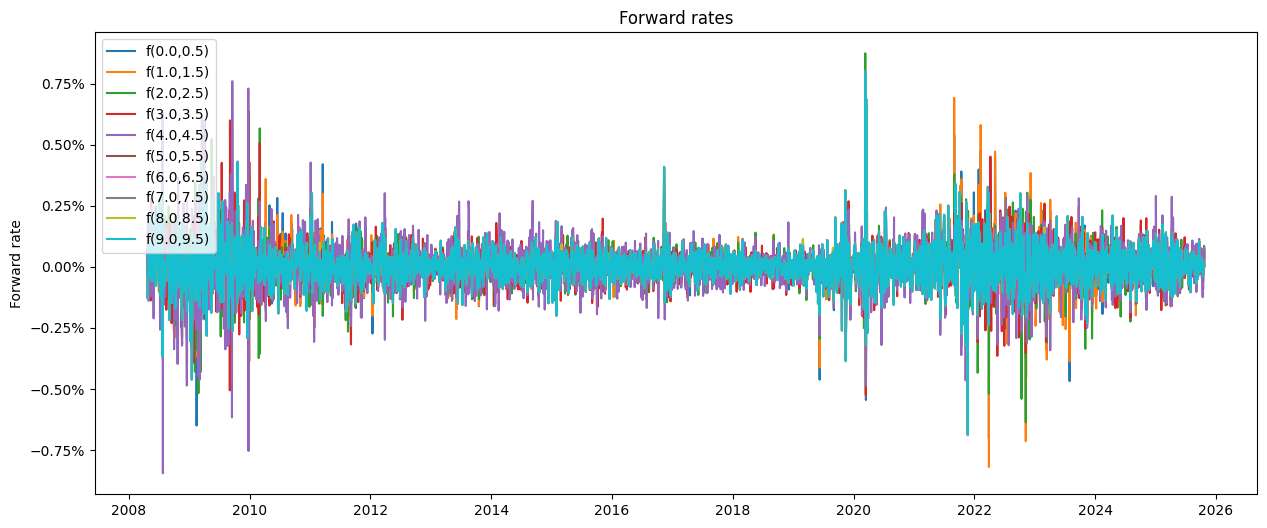

In [221]:
diff_fwds = frac_diff(fwds, d=0.95, threshold=1e-5)
fig, ax = plt.subplots(figsize=(15,6))
for i, (h, s, e) in enumerate(zip(diff_fwds.columns, starts, ends)):
    if i % 2 == 0:
        ax.plot(diff_fwds.index, diff_fwds[h], label=f"f({s.round(2)},{e.round(2)})")

ax.set_title("Forward rates")
ax.set_ylabel("Forward rate")
ax.yaxis.set_major_formatter('{x:.2%}')
ax.legend(loc='upper left')
plt.show()

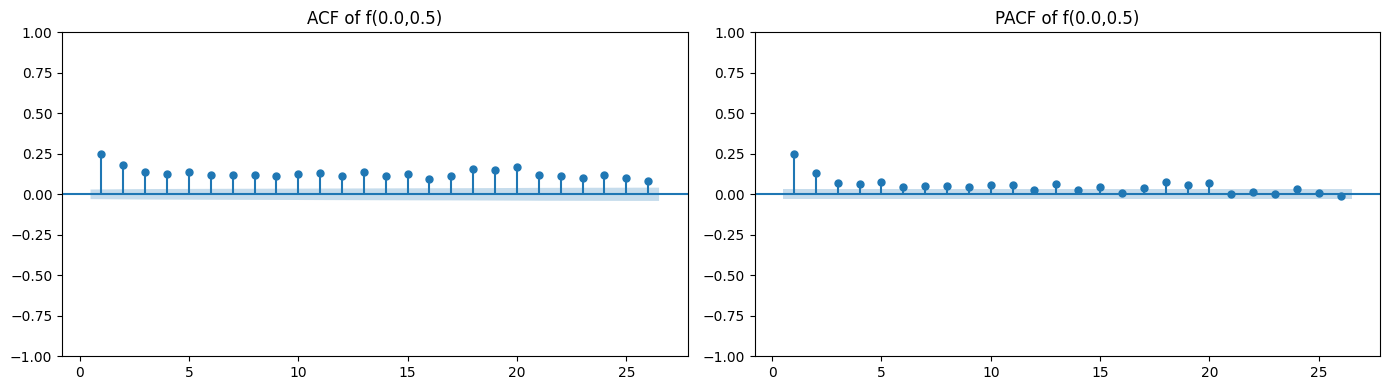

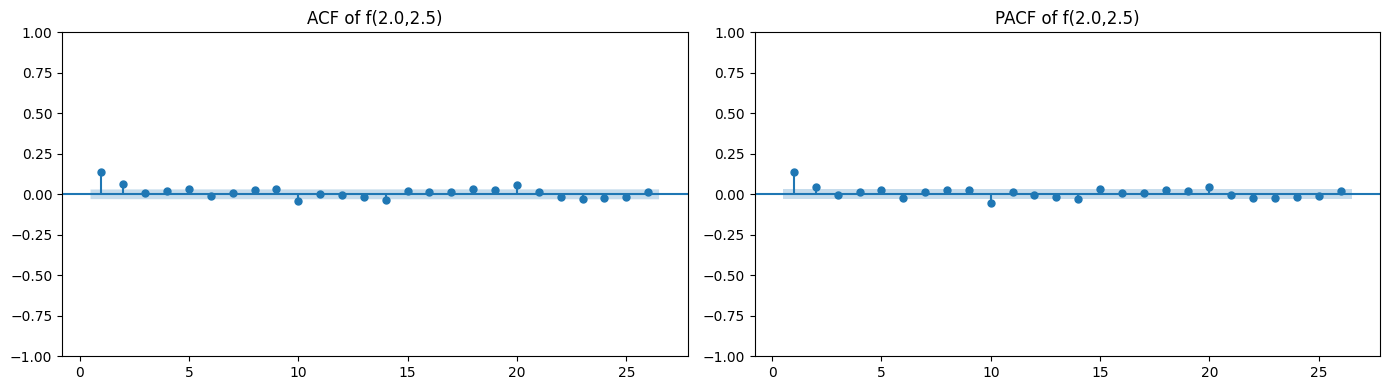

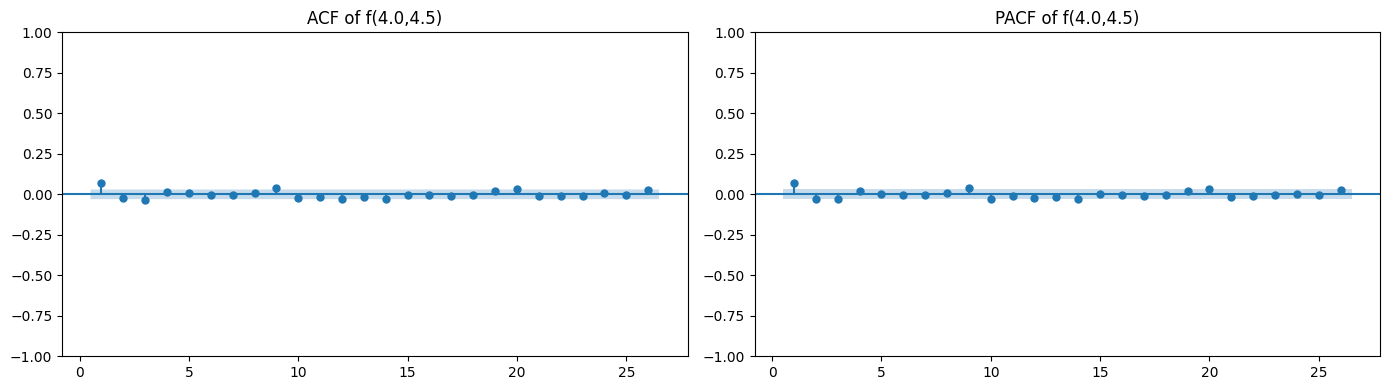

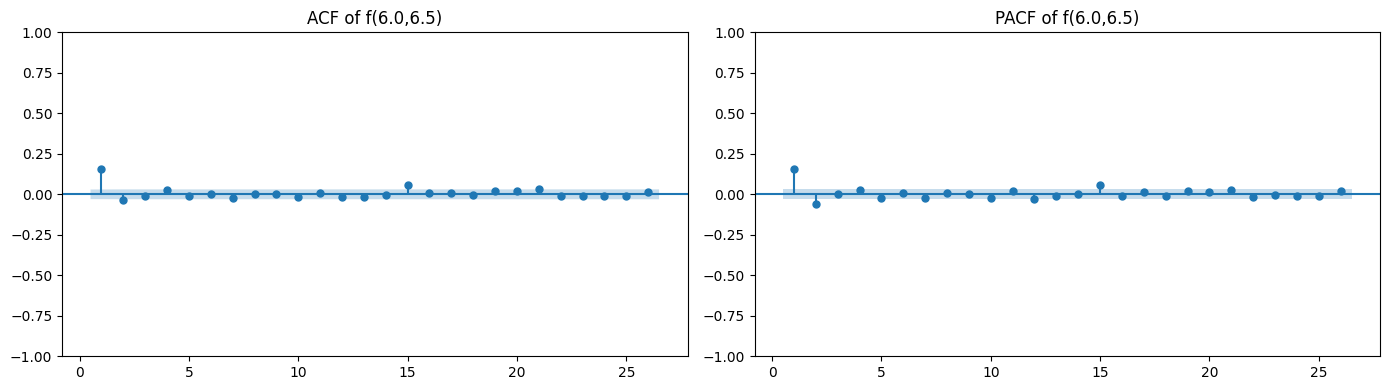

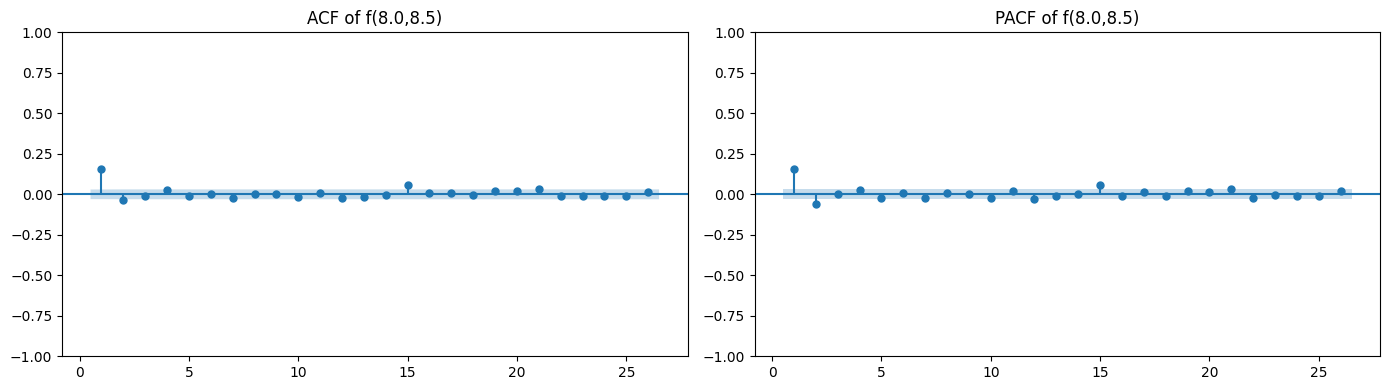

In [224]:
diff_fwds = frac_diff(fwds, d=0.95, threshold=1e-5)

for i, (h, s, e) in enumerate(zip(diff_fwds.columns, starts, ends)):
    if i % 4 == 0:
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sm.graphics.tsa.plot_acf(diff_fwds[h], lags=26, ax=axes[0], zero=False)
        axes[0].set_title(f"ACF of f({s.round(2)},{e.round(2)})")
        
        sm.graphics.tsa.plot_pacf(diff_fwds[h], lags=26, ax=axes[1], method="ywm", zero=False)
        axes[1].set_title(f"PACF of f({s.round(2)},{e.round(2)})")
        
        plt.tight_layout()
        plt.show()

In [229]:
pca = PCA(n_components=6)
pca.fit(diff_fwds.dropna())
explained_variance = pca.explained_variance_ratio_
explained_variance.sum()

np.float64(0.9804726779854815)

In [182]:
pca.components_

array([[ 0.16045924,  0.22931404,  0.1994088 ,  0.38126737,  0.24878745,
         0.24923748,  0.22941373,  0.23040483,  0.22126518,  0.22236387,
         0.20152206,  0.20268358,  0.20177211,  0.20247561,  0.20148557,
         0.20275433,  0.2013924 ,  0.20260092,  0.20152206,  0.20268358],
       [ 0.53855929,  0.46282688,  0.5151454 ,  0.03192713,  0.05304335,
         0.0524897 , -0.03039171, -0.03055563, -0.05026317, -0.04902691,
        -0.14762611, -0.14707306, -0.14775364, -0.14801045, -0.14696395,
        -0.14708866, -0.14751322, -0.14633928, -0.14762611, -0.14707306],
       [-0.27778562, -0.06492551, -0.17537562,  0.69359256,  0.12440455,
         0.12734264,  0.10989922,  0.11416963,  0.150535  ,  0.15479997,
        -0.17621378, -0.17216514, -0.17596076, -0.17224248, -0.17647194,
        -0.17161612, -0.17648856, -0.17206687, -0.17621378, -0.17216514],
       [-0.00579767,  0.05878593,  0.02910496,  0.53494965, -0.0814056 ,
        -0.08058047, -0.24042629, -0.23877052, -

In [183]:
def local_whittle_d(x, m=None):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    x = x - x.mean()
    n = x.size
    if n < 200:
        raise ValueError("Need ~200+ points for local Whittle to be stable.")

    if m is None:
        m = int(np.floor(n**0.6))
    m = max(20, min(m, n//2 - 1))

    freqs = 2*np.pi*np.arange(1, m+1)/n
    fftx = np.fft.fft(x)
    I = (1/(2*np.pi*n)) * (np.abs(fftx[1:m+1])**2)

    def objective(d):
        if d <= -0.49 or d >= 0.49:
            return 1e9
        w = freqs**(-2*d)
        G = np.mean(I * w)
        return np.log(G) + (2*d/m) * np.sum(np.log(freqs))

    res = minimize(lambda dd: objective(dd[0]), x0=np.array([0.1]), method="Nelder-Mead")
    d_hat = float(res.x[0])
    return d_hat, {"n": n, "m": m, "opt": res}



In [184]:
fwds

,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,9.5,10.0
date,,,,,,,,,,,,,,,,,,,,
2008-01-02,0.061225,0.059313,0.060515,0.074162,0.064173,0.065236,0.064463,0.065531,0.065118,0.065833,0.067259,0.068374,0.067259,0.068374,0.067259,0.068374,0.06763,0.068374,0.067259,0.068374
2008-01-03,0.061176,0.059137,0.0604,0.074942,0.063294,0.064343,0.064303,0.065369,0.065482,0.066202,0.066803,0.06791,0.066803,0.06791,0.066803,0.06791,0.067172,0.06791,0.066803,0.06791
2008-01-04,0.062322,0.060201,0.061524,0.078113,0.065169,0.066249,0.066008,0.067102,0.0666,0.067331,0.067093,0.068205,0.067093,0.068205,0.067093,0.068205,0.067464,0.068205,0.067093,0.068205
2008-01-07,0.063191,0.061851,0.062806,0.081642,0.066267,0.067365,0.066306,0.067405,0.067923,0.068669,0.068654,0.069791,0.068654,0.069791,0.068654,0.069791,0.069033,0.069791,0.068654,0.069791
2008-01-08,0.06442,0.062062,0.063537,0.08057,0.067554,0.068674,0.06774,0.068863,0.069867,0.070635,0.068922,0.070064,0.068922,0.070064,0.068922,0.070064,0.069302,0.070064,0.068922,0.070064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-17,0.045914,0.04326,0.044967,0.047491,0.047895,0.047895,0.049708,0.049981,0.051578,0.051862,0.0583,0.05862,0.05862,0.05862,0.0583,0.05862,0.0583,0.05862,0.0583,0.05862
2025-10-20,0.045966,0.04358,0.045156,0.04795,0.048145,0.048145,0.049963,0.050237,0.051269,0.051551,0.058384,0.058705,0.058705,0.058705,0.058384,0.058705,0.058384,0.058705,0.058384,0.058705
2025-10-21,0.046062,0.043577,0.045203,0.048427,0.047972,0.047972,0.050024,0.050298,0.051597,0.051881,0.058458,0.05878,0.05878,0.05878,0.058458,0.05878,0.058458,0.05878,0.058458,0.05878


In [185]:
local_whittle_d(diff_fwds[8.5])

(-0.422343749999999,
 {'n': 4351,
  'm': 152,
  'opt':        message: Optimization terminated successfully.
         success: True
          status: 0
             fun: -14.23804747835361
               x: [-4.223e-01]
             nit: 19
            nfev: 38
   final_simplex: (array([[-4.223e-01],
                         [-4.224e-01]]), array([-1.424e+01, -1.424e+01]))})

In [186]:
# # Cache curves (speed)

# # Horizon panel: h1..h12 for each curve date
# h_cols = [f"h{k}" for k in range(1, 13)]
# fwds_horizon = pd.DataFrame(index=discounts.index, columns=h_cols)

# # Dated panel built ONLY when the horizon includes that meeting (so ~1y long)
# records = []  # (curve_date, meeting_start, fwd)

# tau_1d = float(np.min(tenors))  # first pillar (1D)

# for ref_date in discounts.index:
#     upcoming = meeting_cal[meeting_cal >= ref_date]
#     if len(upcoming) < 13:
#         continue

#     ms = upcoming[:13]  # 13 meetings -> 12 meeting-to-meeting intervals
#     t0_curve = curves[ref_date]

#     # next available curve date (where the new published rate appears)
#     next_dates = discounts.index[discounts.index > ref_date]
#     next_date = next_dates.min() if len(next_dates) else None

#     for k in range(12):
#         m0, m1 = ms[k], ms[k+1]

#         if m0 == ref_date and k == 0:
#             if next_date is None:
#                 continue  # can't read published rate if no next curve date
#             t1_curve = curves[next_date]
#             # published rate = 1D pillar from the NEXT day's curve
#             fwd = t1_curve.fwd_rate(0.0, tau_1d)

#         else:
#             T0 = yearfrac(ref_date, m0)
#             T1 = yearfrac(ref_date, m1)
#             if T1 > tenors.max():
#                 continue
#             fwd = t0_curve.fwd_rate(T0, T1)

#         fwds_horizon.loc[ref_date, f"h{k+1}"] = t0_curve.inst_fwd((k+1)*30/360)
#         records.append((ref_date, m0, fwd))   # dated by meeting start

# fwds_dated = (
#     pd.DataFrame(records, columns=["curve_date", "meeting_start", "fwd"])
#       .pivot(index="curve_date", columns="meeting_start", values="fwd")
#       .sort_index()
# )

In [187]:
# fig, ax = plt.subplots(figsize=(15,6))
# for h in fwds_horizon.columns:
#     ax.plot(fwds_horizon.index, fwds_horizon[h], label=f"{h}")

# ax.set_title("Forward rates")
# ax.set_ylabel("Forward rate")
# ax.yaxis.set_major_formatter('{x:.2%}')
# ax.grid(True)
# ax.legend(loc='upper left')
# plt.show()

In [188]:
import statsmodels.api as sm

h12_diffs = fwds_horizon['h12'].diff()
h12_diffs = h12_diffs.dropna()

# acf
fig, ax = plt.subplots(figsize=(10, 4))
sm.graphics.tsa.plot_acf(h12_diffs, lags=26, ax=ax)
ax.set_title("ACF of 12-meeting forward rate changes")
plt.show()

# pacf
fig, ax = plt.subplots(figsize=(10, 4))
sm.graphics.tsa.plot_pacf(h12_diffs, lags=26, ax=ax)
ax.set_title("PACF of 12-meeting forward rate changes")
plt.show()

NameError: name 'fwds_horizon' is not defined

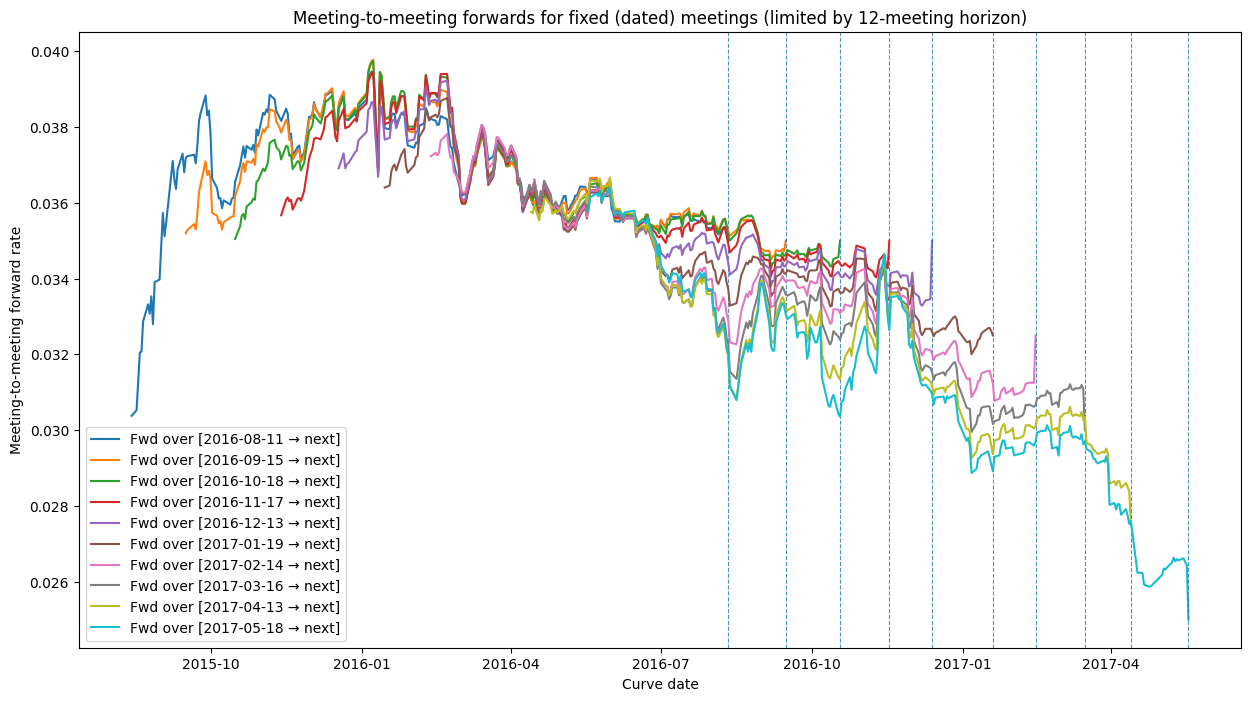

In [ ]:
fig, ax = plt.subplots(figsize=(15,8))

meetings_to_plot = fwds_dated.columns[100:110]

for m0 in meetings_to_plot:
    s = fwds_dated[m0].dropna().sort_index()
    if s.empty:
        continue
    ax.plot(s.index, s.values, label=f"Fwd over [{m0.date()} → next]")
    ax.axvline(m0, linestyle="--", linewidth=0.8, alpha=0.8)

ax.set_title("Meeting-to-meeting forwards for fixed (dated) meetings (limited by 12-meeting horizon)")
ax.set_xlabel("Curve date")
ax.set_ylabel("Meeting-to-meeting forward rate")
ax.legend()
plt.show()


In [ ]:
jumps = {}
for h in fwds_dated.columns:
    serie = fwds_dated[h].dropna().sort_index()
    if serie.empty:
        continue    
    jumps[h] = serie.diff().dropna()[-1] 

/var/folders/cp/l432p0ns1t38qmnyr_3l3r000000gn/T/ipykernel_84675/1451636671.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  jumps[h] = serie.diff().dropna()[-1]


In [ ]:
jumps = np.array(list(jumps.values()))

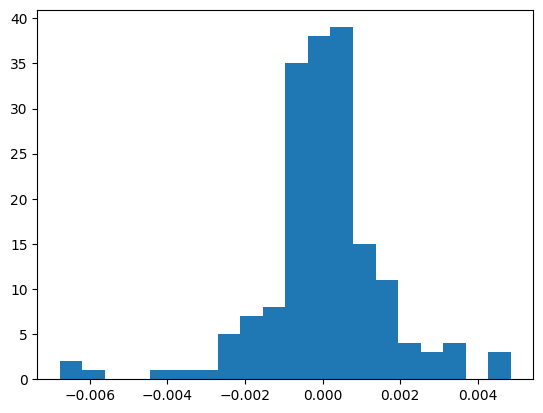

In [ ]:
plt.hist(jumps, bins=20)
plt.show()

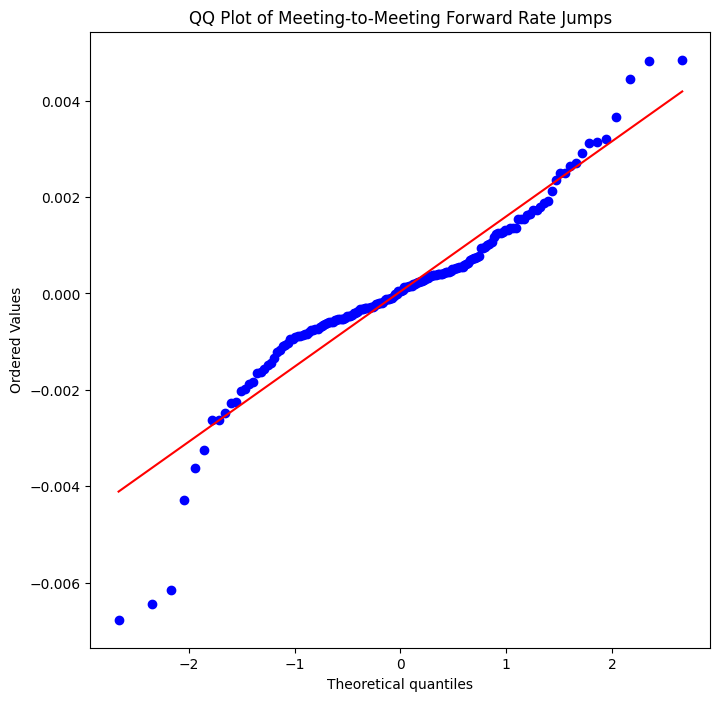

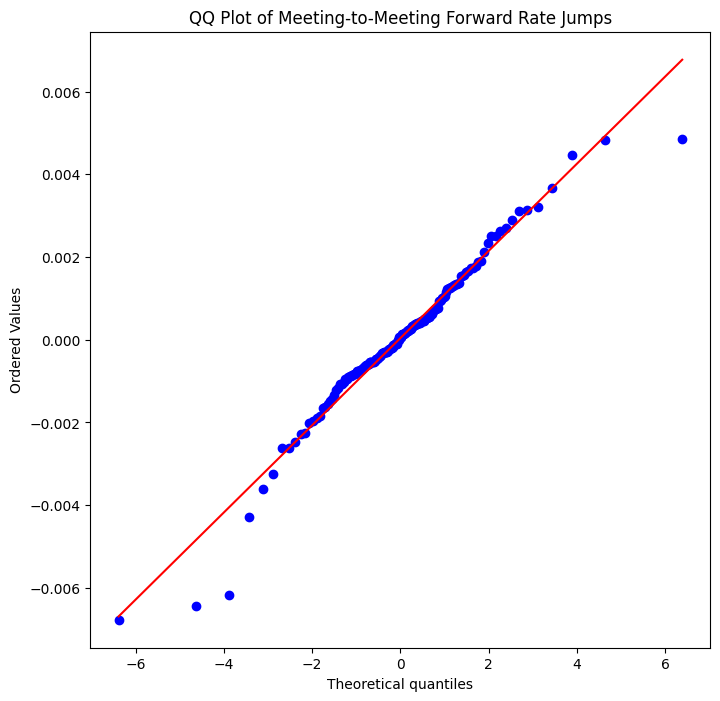

In [ ]:

fig, ax = plt.subplots(figsize=(8,8))
stats.probplot(jumps, dist="norm", plot=ax)
ax.set_title("QQ Plot of Meeting-to-Meeting Forward Rate Jumps")
plt.show()

fig, ax = plt.subplots(figsize=(8,8))
stats.probplot(jumps, dist="t", sparams=(3,), plot=ax)
ax.set_title("QQ Plot of Meeting-to-Meeting Forward Rate Jumps")
plt.show()

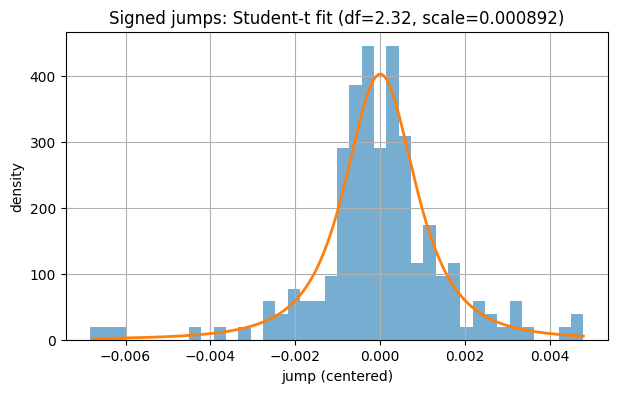

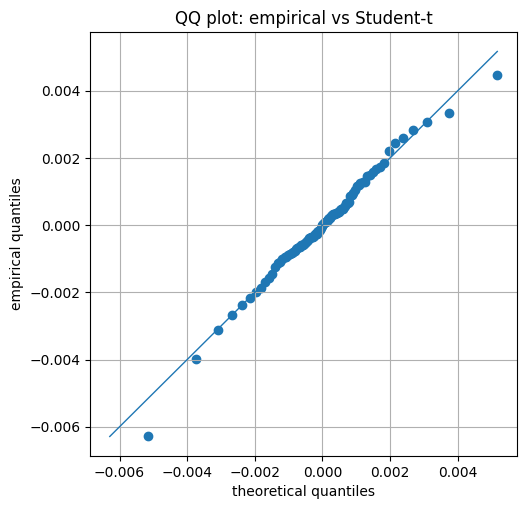

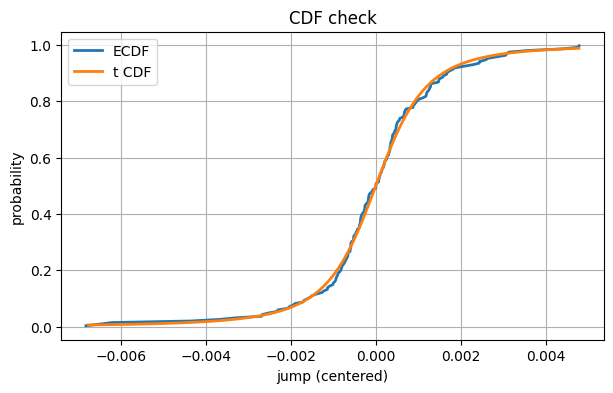

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy.optimize import minimize


# ---------- fitting ----------

def fit_student_t_loc0(jumps):
    """Fit Student-t with loc fixed to 0 by MLE. Returns df, scale."""
    x = np.asarray(jumps, float)
    x = x[np.isfinite(x)]
    x = x - np.median(x)  # robust centering (optional)

    def nll(theta):
        df = 2.0 + np.exp(theta[0])   # df>2
        scale = np.exp(theta[1])      # scale>0
        return -np.sum(t.logpdf(x, df=df, loc=0.0, scale=scale))

    res = minimize(
        nll,
        x0=np.array([np.log(10.0 - 2.0), np.log(np.std(x) + 1e-12)]),
        method="L-BFGS-B",
    )
    df = 2.0 + np.exp(res.x[0])
    scale = np.exp(res.x[1])
    return {"df": df, "loc": 0.0, "scale": scale, "x_centered": x, "opt": res}


def fit_half_t(magnitudes):
    """Fit folded/half-t to u=|J| (support u>=0). Returns df, scale."""
    u = np.asarray(magnitudes, float)
    u = u[np.isfinite(u)]
    u = u[u >= 0]

    def nll(theta):
        df = 2.0 + np.exp(theta[0])   # df>2
        scale = np.exp(theta[1])
        ll = np.log(2.0) + t.logpdf(u, df=df, loc=0.0, scale=scale)  # folded t
        return -np.sum(ll)

    res = minimize(
        nll,
        x0=np.array([np.log(10.0 - 2.0), np.log(np.std(u) + 1e-12)]),
        method="L-BFGS-B",
    )
    df = 2.0 + np.exp(res.x[0])
    scale = np.exp(res.x[1])
    return {"df": df, "scale": scale, "u": u, "opt": res}


# ---------- plotting ----------

def _ecdf(x):
    x = np.sort(x)
    p = (np.arange(1, x.size + 1) - 0.5) / x.size
    return x, p


def plot_student_t_fit(jumps, bins=40, qq_points=99):
    fit = fit_student_t_loc0(jumps)
    x = fit["x_centered"]
    df, loc, scale = fit["df"], fit["loc"], fit["scale"]

    # 1) Histogram + fitted pdf
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(x, bins=bins, density=True, alpha=0.6)
    xx = np.linspace(np.quantile(x, 0.001), np.quantile(x, 0.999), 500)
    ax.plot(xx, t.pdf(xx, df=df, loc=loc, scale=scale), linewidth=2)
    ax.set_title(f"Signed jumps: Student-t fit (df={df:.2f}, scale={scale:.4g})")
    ax.set_xlabel("jump (centered)")
    ax.set_ylabel("density")
    ax.grid(True)

    # 2) QQ plot
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    p = np.linspace(0.01, 0.99, qq_points)
    theo = t.ppf(p, df=df, loc=loc, scale=scale)
    emp = np.quantile(x, p)
    ax.scatter(theo, emp)
    lo = min(theo.min(), emp.min())
    hi = max(theo.max(), emp.max())
    ax.plot([lo, hi], [lo, hi], linewidth=1)
    ax.set_title("QQ plot: empirical vs Student-t")
    ax.set_xlabel("theoretical quantiles")
    ax.set_ylabel("empirical quantiles")
    ax.grid(True)

    # 3) CDF check (ECDF vs fitted CDF)
    fig, ax = plt.subplots(figsize=(7, 4))
    xs, ps = _ecdf(x)
    ax.plot(xs, ps, linewidth=2, label="ECDF")
    ax.plot(xx, t.cdf(xx, df=df, loc=loc, scale=scale), linewidth=2, label="t CDF")
    ax.set_title("CDF check")
    ax.set_xlabel("jump (centered)")
    ax.set_ylabel("probability")
    ax.grid(True)
    ax.legend()

    plt.show()
    return fit


fit = plot_student_t_fit(jumps)   # signed jumps


In [ ]:
n_sim = 10_000
n_steps = 252
dt = 1/252

df = np.zeros(shape=(n_sim, n_steps))


In [ ]:
# [1] Imports + configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats
from scipy.optimize import minimize

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.statespace.sarimax import SARIMAX

# arch for GARCH (recommended). Fallback not provided here because you asked "implement all things".
# If you cannot install it, tell me and I will paste a pure-numpy fallback.
from arch import arch_model

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)


In [ ]:
# [2] Build forward-difference panel Y_t = ΔF_t across horizons
# Requires: fwds_horizon built in your notebook (h1..h12 forward levels)

def build_diff_matrix(fwds_horizon: pd.DataFrame, cols=None, dropna="any") -> pd.DataFrame:
    if cols is None:
        cols = [c for c in fwds_horizon.columns if str(c).startswith("h")]
    X = fwds_horizon[cols].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    Y = X.diff()
    if dropna == "any":
        Y = Y.dropna(axis=0, how="any")
    elif dropna == "all":
        Y = Y.dropna(axis=0, how="all")
    return Y

Y = build_diff_matrix(fwds_horizon, cols=[f"h{k}" for k in range(1,13)], dropna="any")
Y.head(), Y.shape


(                  h1        h2        h3        h4        h5        h6  \
 date                                                                     
 2008-01-03 -0.000019 -0.000027 -0.000041 -0.000060 -0.000085 -0.000115   
 2008-01-04  0.000822  0.001155  0.001349  0.001406  0.001324  0.001104   
 2008-01-07  0.000514  0.000730  0.000914  0.001065  0.001184  0.001270   
 2008-01-08  0.000992  0.001397  0.001572  0.001514  0.001226  0.000706   
 2008-01-09  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
 
                   h7        h8        h9       h10       h11       h12  
 date                                                                    
 2008-01-03 -0.000158 -0.000186 -0.000199 -0.000197 -0.000179 -0.000146  
 2008-01-04  0.001074  0.001055  0.001047  0.001051  0.001067  0.001094  
 2008-01-07  0.001537  0.001710  0.001790  0.001777  0.001670  0.001469  
 2008-01-08  0.000353  0.000126  0.000023  0.000046  0.000194  0.000466  
 2008-01-09  0.000000  0.0000

Explained variance ratio (PC1..PC3): [0.7899 0.1704 0.036 ]


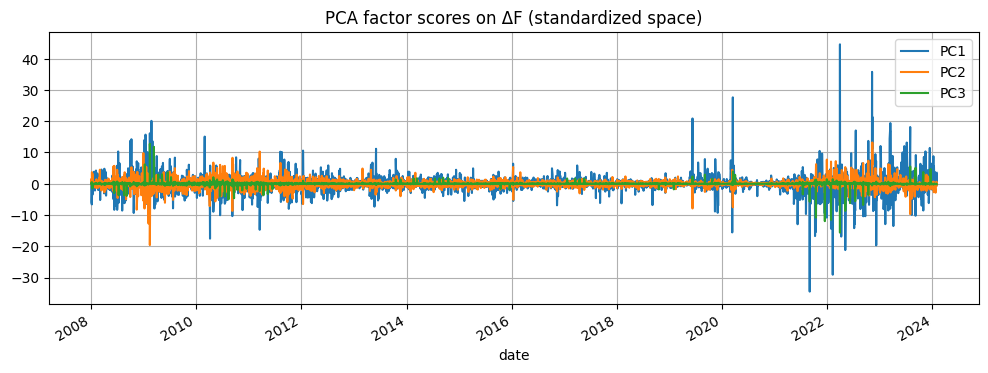

In [ ]:
# [3] PCA on ΔF panel (historical, fixed loadings)
# PCA is cross-sectional compression; it is "historical" because it is estimated on past data.
# To avoid lookahead in evaluation, fit on a training window and apply out-of-sample.

def pca_fit(Y: pd.DataFrame, n_factors=3, standardize=True):
    X = Y.values
    mu = np.nanmean(X, axis=0)
    Xc = X - mu

    if standardize:
        s = np.nanstd(Xc, axis=0, ddof=1)
        s[s == 0] = 1.0
        Xcs = Xc / s
    else:
        s = np.ones(X.shape[1])
        Xcs = Xc

    S = np.cov(Xcs.T, ddof=1)
    evals, evecs = np.linalg.eigh(S)
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]

    W = evecs[:, :n_factors]  # (m x r)
    Z = Xcs @ W               # (T x r)
    Xhat = Z @ W.T
    E = Xcs - Xhat

    return {
        "mu": mu,
        "scale": s,
        "W": W,
        "evals": evals,
        "Z": pd.DataFrame(Z, index=Y.index, columns=[f"PC{k+1}" for k in range(n_factors)]),
        "E": pd.DataFrame(E, index=Y.index, columns=Y.columns),
        "cols": list(Y.columns),
    }

pca = pca_fit(Y, n_factors=3, standardize=True)
expl = (pca["evals"][:3] / pca["evals"].sum())
print("Explained variance ratio (PC1..PC3):", expl.round(4))

pca["Z"].plot(title="PCA factor scores on ΔF (standardized space)")
plt.show()


In [ ]:
# [4] Persistence estimation: Local Whittle estimator for long-memory d
# d in (0,0.5) indicates stationary long memory.

def local_whittle_d(x, m=None):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    x = x - x.mean()
    n = x.size
    if n < 200:
        raise ValueError("Need ~200+ points for local Whittle to be stable.")

    if m is None:
        m = int(np.floor(n**0.6))
    m = max(20, min(m, n//2 - 1))

    freqs = 2*np.pi*np.arange(1, m+1)/n
    fftx = np.fft.fft(x)
    I = (1/(2*np.pi*n)) * (np.abs(fftx[1:m+1])**2)

    def objective(d):
        if d <= -0.49 or d >= 0.49:
            return 1e9
        w = freqs**(-2*d)
        G = np.mean(I * w)
        return np.log(G) + (2*d/m) * np.sum(np.log(freqs))

    res = minimize(lambda dd: objective(dd[0]), x0=np.array([0.1]), method="Nelder-Mead")
    d_hat = float(res.x[0])
    return d_hat, {"n": n, "m": m, "opt": res}

d_est = {}
for c in pca["Z"].columns:
    d_hat, info = local_whittle_d(pca["Z"][c].values)
    d_est[c] = d_hat
    print(f"{c}: d_hat={d_hat:.3f} (m={info['m']})")


PC1: d_hat=-0.285 (m=144)
PC2: d_hat=-0.277 (m=144)
PC3: d_hat=-0.108 (m=144)


In [ ]:
# [5] Fractional differencing + inverse (for ARFIMA approximation)

def fracdiff_weights(d, n_lags):
    w = np.zeros(n_lags+1)
    w[0] = 1.0
    for k in range(1, n_lags+1):
        w[k] = w[k-1] * ((k-1 - d) / k)
    return w

def fracdiff_series(x, d, n_lags=200):
    x = np.asarray(x, float)
    w = fracdiff_weights(d, n_lags)
    y = np.full_like(x, np.nan, dtype=float)
    for t in range(n_lags, len(x)):
        y[t] = np.dot(w, x[t - np.arange(0, n_lags+1)])
    return y

def fracintegrate_series(x_fd, d, n_lags=200):
    """
    Invert fractional differencing using (1-L)^(-d) with truncated psi weights.
    Unlike the previous version, this computes y[t] using psi[0..min(t,n_lags)].
    That avoids NaNs at the start and eliminates the artificial flat segment.
    """
    x_fd = np.asarray(x_fd, float)

    # psi_0=1, psi_k = psi_{k-1} * ((k-1 + d)/k)
    psi = np.zeros(n_lags + 1)
    psi[0] = 1.0
    for k in range(1, n_lags + 1):
        psi[k] = psi[k-1] * ((k-1 + d) / k)

    y = np.zeros_like(x_fd, dtype=float)
    for t in range(len(x_fd)):
        L = min(t, n_lags)
        # y[t] = sum_{k=0..L} psi_k * x_fd[t-k]
        y[t] = np.dot(psi[:L+1], x_fd[t - np.arange(0, L+1)])
    return y


In [ ]:
# [5] Fractional differencing + inverse (for ARFIMA approximation)

def fracdiff_weights(d, n_lags):
    w = np.zeros(n_lags+1)
    w[0] = 1.0
    for k in range(1, n_lags+1):
        w[k] = w[k-1] * ((k-1 - d) / k)
    return w

def fracdiff_series(x, d, n_lags=200):
    x = np.asarray(x, float)
    w = fracdiff_weights(d, n_lags)
    y = np.full_like(x, np.nan, dtype=float)
    for t in range(n_lags, len(x)):
        y[t] = np.dot(w, x[t - np.arange(0, n_lags+1)])
    return y

# [18] HARD FIX: overwrite fracintegrate_series() in-place so ANY code uses the no-NaN version
# This eliminates the "NaN prefix then fill with 0" effect, even if older code cells are still in memory.

def fracintegrate_series(x_fd, d, n_lags=200):
    """
    Invert fractional differencing using (1-L)^(-d) with truncated psi weights.
    Computes y[t] with available history so there is NO NaN prefix.
    """
    x_fd = np.asarray(x_fd, float)

    psi = np.zeros(n_lags + 1)
    psi[0] = 1.0
    for k in range(1, n_lags + 1):
        psi[k] = psi[k-1] * ((k-1 + d) / k)

    y = np.zeros_like(x_fd, dtype=float)
    for t in range(len(x_fd)):
        L = min(t, n_lags)
        y[t] = np.dot(psi[:L+1], x_fd[t - np.arange(0, L+1)])
    return y



In [ ]:
# [6] ARFIMA approximation: estimate d, then fit ARMA(p,q) on fractionally differenced series
# We select (p,q) by BIC over a small grid.

def fit_arma_on_fracdiff(z, d, p_max=3, q_max=3, n_lags_fd=150):
    z = np.asarray(z, float)
    z = z - np.nanmean(z)
    z_fd = fracdiff_series(z, d, n_lags=n_lags_fd)
    z_fd = pd.Series(z_fd).dropna()

    best = None
    for p in range(p_max+1):
        for q in range(q_max+1):
            if p == 0 and q == 0:
                continue
            try:
                mod = SARIMAX(z_fd, order=(p,0,q), trend="n",
                              enforce_stationarity=True, enforce_invertibility=True)
                res = mod.fit(disp=False)
                if best is None or res.bic < best["bic"]:
                    best = {"p": p, "q": q, "bic": res.bic, "res": res, "z_fd": z_fd}
            except Exception:
                continue

    if best is None:
        raise RuntimeError("ARMA grid search failed. Check series length / stationarity.")
    return best

arma_fits = {}
for c in pca["Z"].columns:
    d = float(d_est[c])
    fit = fit_arma_on_fracdiff(pca["Z"][c].values, d=d, p_max=3, q_max=3, n_lags_fd=150)
    arma_fits[c] = fit
    print(f"{c}: d={d:.3f}, ARMA({fit['p']},{fit['q']}) BIC={fit['bic']:.1f}")


/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11

PC1: d=-0.285, ARMA(3,1) BIC=19376.8


/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11

PC2: d=-0.277, ARMA(3,1) BIC=13646.6


/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11

PC3: d=-0.108, ARMA(1,3) BIC=7798.9


/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# [7] Heteroskedasticity + tail diagnostics to decide Gaussian vs Student-t for GARCH
# We will fit both and select by AIC (and also print ARCH LM / excess kurtosis).

from scipy.stats import kurtosis

def select_garch_dist(resid, arch_lags=10, kurt_thresh=1.0):
    resid = np.asarray(resid, float)
    resid = resid[np.isfinite(resid)]
    resid = resid - resid.mean()

    arch_stat, arch_p, *_ = het_arch(resid, nlags=arch_lags)
    ex_kurt = kurtosis(resid, fisher=True, bias=False)

    return {"arch_p": float(arch_p), "excess_kurt": float(ex_kurt), "arch_stat": float(arch_stat)}

def fit_garch_choose(resid):
    resid = np.asarray(resid, float)
    resid = resid[np.isfinite(resid)]
    resid = resid - resid.mean()

    # Normal
    mN = arch_model(resid, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
    rN = mN.fit(disp="off")

    # Student-t
    mT = arch_model(resid, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
    rT = mT.fit(disp="off")

    chosen = rT if rT.aic < rN.aic else rN
    return {"normal": rN, "t": rT, "chosen": chosen}

garch_fits = {}
for c, fit in arma_fits.items():
    resid = fit["res"].resid.values
    diag = select_garch_dist(resid)

    gg = fit_garch_choose(resid)
    garch_fits[c] = {"diag": diag, **gg}

    ch = gg["chosen"]
    distname = ch.model.distribution.name
    params = ch.params
    a = float(params.get("alpha[1]", np.nan))
    b = float(params.get("beta[1]", np.nan))
    nu = float(params.get("nu", np.nan)) if "nu" in params.index else np.nan

    print(f"{c}: ARCH p={diag['arch_p']:.3g}, excess_kurt={diag['excess_kurt']:.2f}, "
          f"chosen={distname}, alpha+beta={a+b:.3f}, nu={nu if np.isfinite(nu) else 'NA'}")


PC1: ARCH p=2.39e-11, excess_kurt=32.34, chosen=Standardized Student's t, alpha+beta=1.000, nu=3.41702956216635
PC2: ARCH p=1.07e-45, excess_kurt=17.71, chosen=Standardized Student's t, alpha+beta=1.000, nu=4.01761968965275
PC3: ARCH p=1, excess_kurt=230.53, chosen=Standardized Student's t, alpha+beta=1.000, nu=2.4323130114100526



==================== PC1 ====================
Local Whittle d (raw factor): -0.285


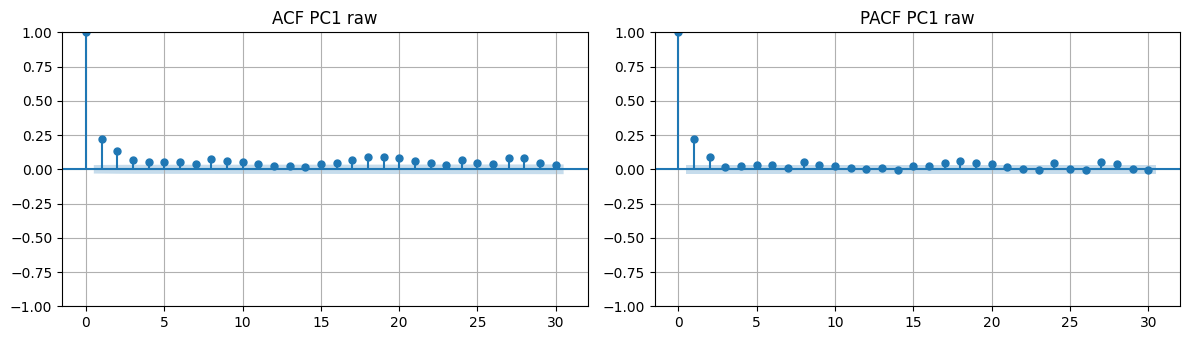

ARMA(3,1) on fracdiff series BIC=19376.8
Local Whittle d (ARMA residuals): -0.044
Ljung-Box residuals:
       lb_stat  lb_pvalue
10   4.735152   0.908154
20  25.605883   0.179226
ARCH LM p-value (resid): 2.492e-11
Ljung-Box resid^2:
        lb_stat     lb_pvalue
10   89.666289  6.237287e-15
20  118.745768  4.865584e-16
GARCH chosen dist: Standardized Student's t, AIC=15859.0
Ljung-Box standardized resid:
       lb_stat  lb_pvalue
10   9.371959   0.497204
20  22.474751   0.315315
Ljung-Box standardized resid^2:
      lb_stat  lb_pvalue
10  1.554861   0.998754
20  3.346867   0.999990


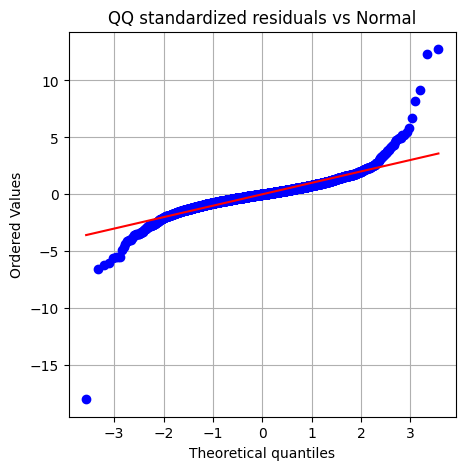

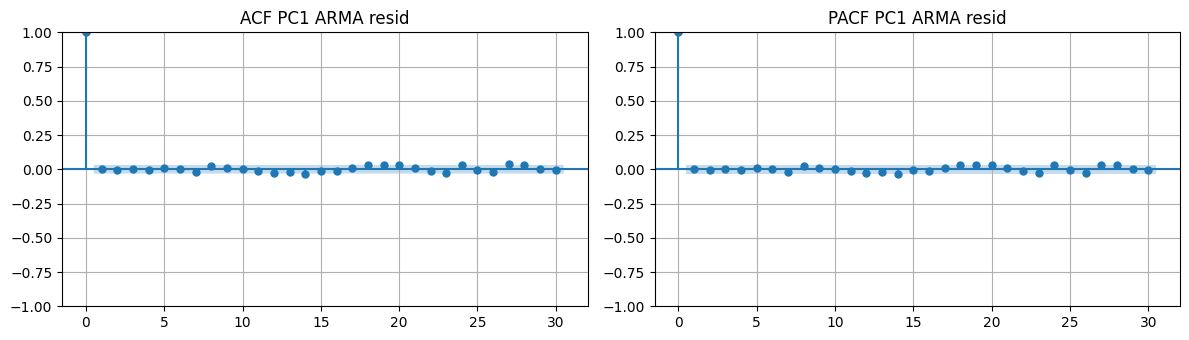

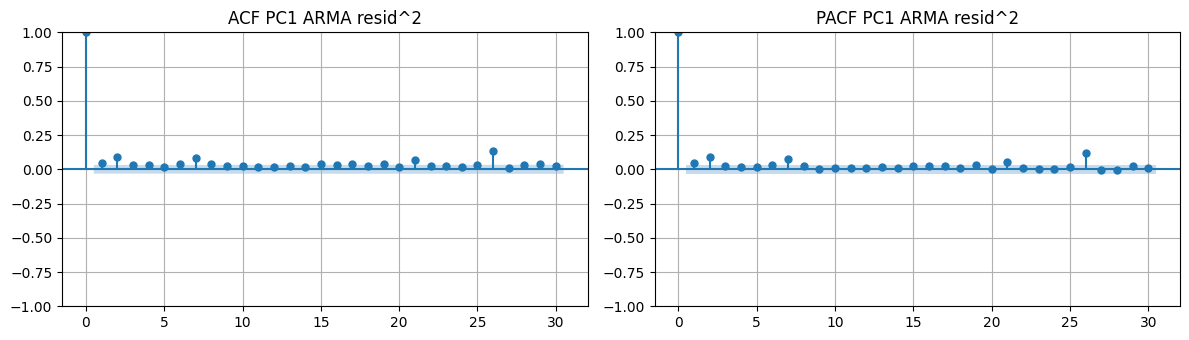

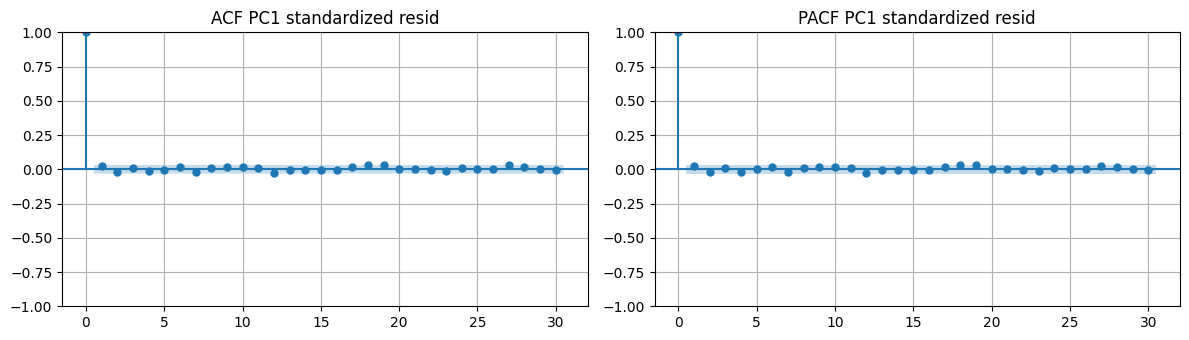

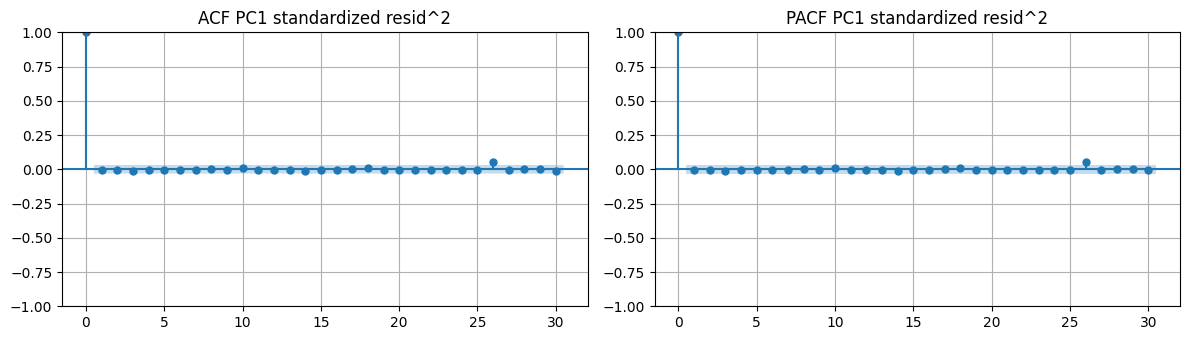


==================== PC2 ====================
Local Whittle d (raw factor): -0.277


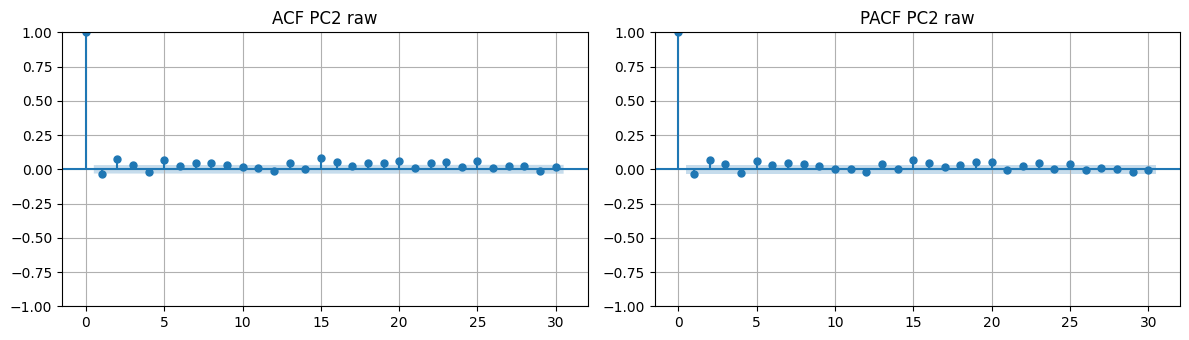

ARMA(3,1) on fracdiff series BIC=13646.6
Local Whittle d (ARMA residuals): -0.003
Ljung-Box residuals:
       lb_stat  lb_pvalue
10  24.134410   0.007252
20  58.572732   0.000012
ARCH LM p-value (resid): 9.138e-46
Ljung-Box resid^2:
        lb_stat     lb_pvalue
10  324.374357  1.080525e-63
20  481.723411  1.939563e-89
GARCH chosen dist: Standardized Student's t, AIC=11166.5
Ljung-Box standardized resid:
       lb_stat  lb_pvalue
10  15.716123   0.108052
20  20.980568   0.398277
Ljung-Box standardized resid^2:
       lb_stat  lb_pvalue
10  12.903819   0.229099
20  24.503787   0.221078


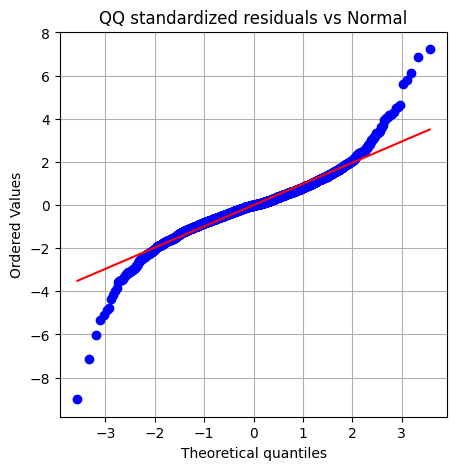

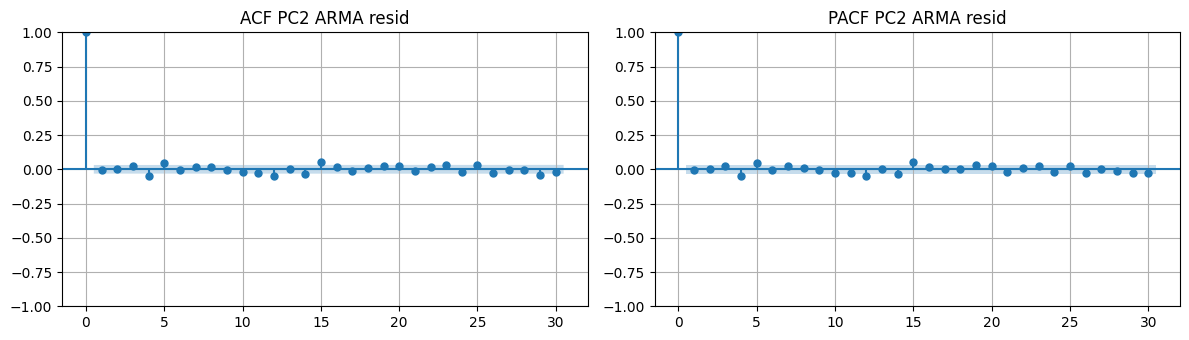

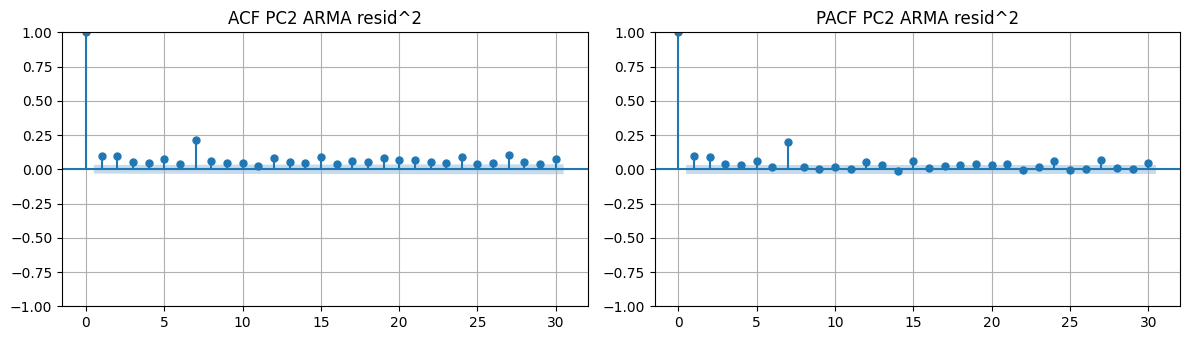

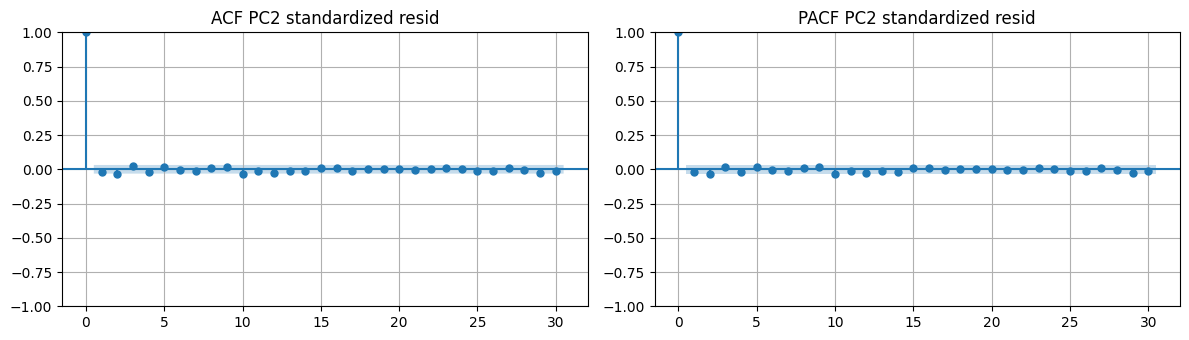

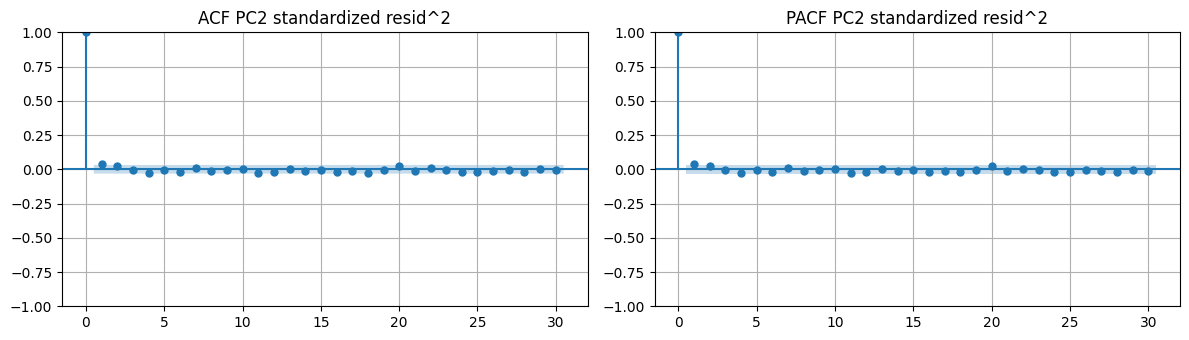


==================== PC3 ====================
Local Whittle d (raw factor): -0.108


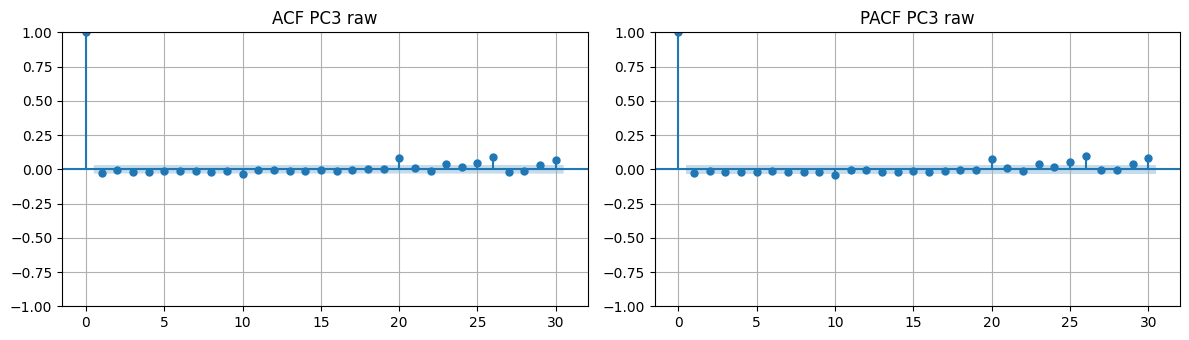

ARMA(1,3) on fracdiff series BIC=7798.9
Local Whittle d (ARMA residuals): -0.038
Ljung-Box residuals:
       lb_stat  lb_pvalue
10  13.660277   0.189059
20  45.122645   0.001062
ARCH LM p-value (resid): 1
Ljung-Box resid^2:
       lb_stat     lb_pvalue
10   0.243010  9.999998e-01
20  72.792691  6.333501e-08
GARCH chosen dist: Standardized Student's t, AIC=-4282.5
Ljung-Box standardized resid:
        lb_stat     lb_pvalue
10    4.582185  9.172871e-01
20  109.940598  2.013658e-14
Ljung-Box standardized resid^2:
        lb_stat     lb_pvalue
10    0.304043  9.999994e-01
20  331.698238  2.596406e-58


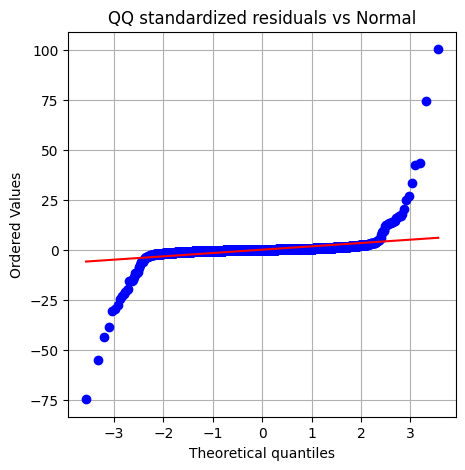

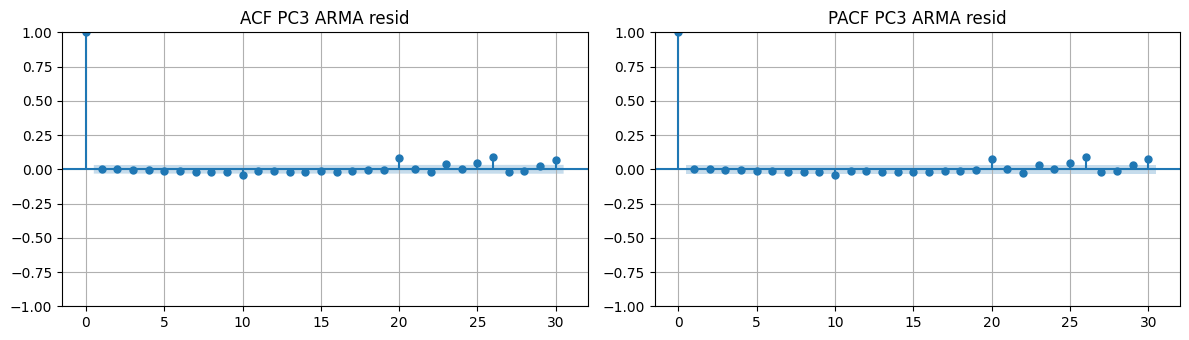

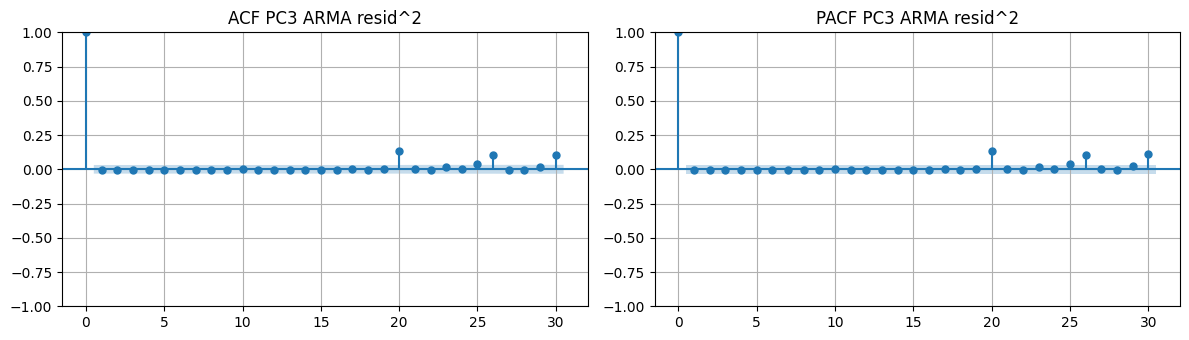

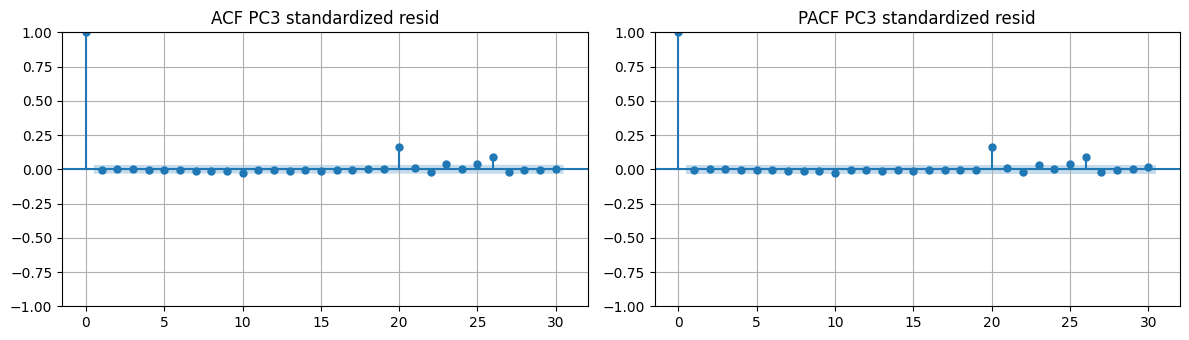

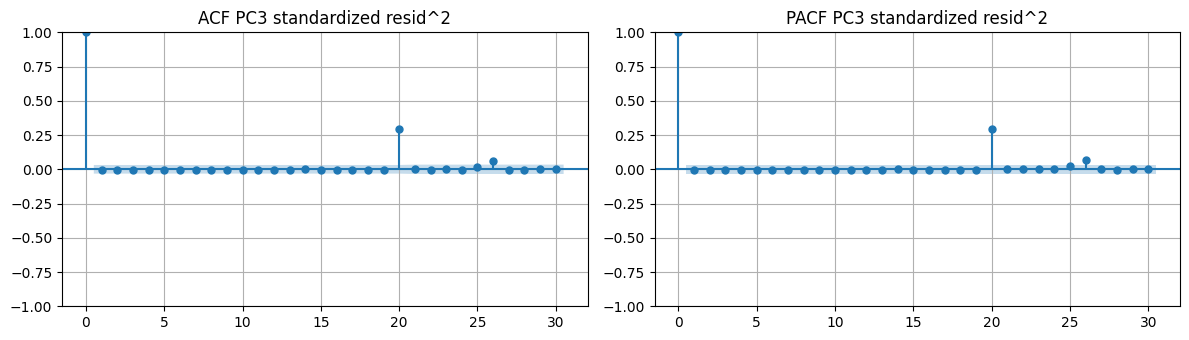

In [ ]:
# [8] Diagnostics: persistence + heteroskedasticity checks (pre/post modeling)

def plot_acf_pacf(x, title="", lags=40):
    fig, axes = plt.subplots(1,2, figsize=(12,3.5))
    sm.graphics.tsa.plot_acf(x, lags=lags, ax=axes[0])
    sm.graphics.tsa.plot_pacf(x, lags=lags, ax=axes[1], method="ywm")
    axes[0].set_title(f"ACF {title}")
    axes[1].set_title(f"PACF {title}")
    plt.tight_layout()
    plt.show()

def factor_diagnostics(c):
    print(f"\n==================== {c} ====================")

    z = pca["Z"][c].values
    d_raw = d_est[c]
    print(f"Local Whittle d (raw factor): {d_raw:.3f}")

    # ACF/PACF raw factor
    plot_acf_pacf(z - np.nanmean(z), title=f"{c} raw", lags=30)

    # ARMA residuals on frac-diff series
    arma_res = arma_fits[c]["res"]
    resid = arma_res.resid.values
    resid = resid[np.isfinite(resid)]
    print(f"ARMA({arma_fits[c]['p']},{arma_fits[c]['q']}) on fracdiff series BIC={arma_fits[c]['bic']:.1f}")

    # Persistence of residuals (should be closer to 0 if ARFIMA structure captured memory well)
    try:
        d_res, _ = local_whittle_d(resid)
        print(f"Local Whittle d (ARMA residuals): {d_res:.3f}")
    except Exception as e:
        print("Local Whittle on residuals failed:", e)

    # Residual serial correlation
    lb = acorr_ljungbox(resid, lags=[10,20], return_df=True)
    print("Ljung-Box residuals:\n", lb)

    # Heteroskedasticity
    arch = het_arch(resid, nlags=10)
    print(f"ARCH LM p-value (resid): {arch[1]:.4g}")
    lb2 = acorr_ljungbox(resid**2, lags=[10,20], return_df=True)
    print("Ljung-Box resid^2:\n", lb2)

    # Standardize residuals by fitted GARCH conditional vol and check again
    garch_res = garch_fits[c]["chosen"]
    cond_vol = np.asarray(garch_res.conditional_volatility, float)
    rr = resid[-len(cond_vol):]
    zstd = rr / (cond_vol + 1e-12)

    print(f"GARCH chosen dist: {garch_res.model.distribution.name}, AIC={garch_res.aic:.1f}")
    lb_std = acorr_ljungbox(zstd, lags=[10,20], return_df=True)
    lb2_std = acorr_ljungbox(zstd**2, lags=[10,20], return_df=True)
    print("Ljung-Box standardized resid:\n", lb_std)
    print("Ljung-Box standardized resid^2:\n", lb2_std)

    # QQ on standardized residuals vs the chosen innovation distribution
    fig, ax = plt.subplots(figsize=(5,5))
    if garch_res.model.distribution.name.lower().startswith("student"):
        nu = float(garch_res.params["nu"])
        stats.probplot(zstd, dist=stats.t, sparams=(nu,), plot=ax)
        ax.set_title(f"QQ standardized residuals vs t(df={nu:.1f})")
    else:
        stats.probplot(zstd, dist="norm", plot=ax)
        ax.set_title("QQ standardized residuals vs Normal")
    plt.show()

    plot_acf_pacf(resid, title=f"{c} ARMA resid", lags=30)
    plot_acf_pacf(resid**2, title=f"{c} ARMA resid^2", lags=30)
    plot_acf_pacf(zstd, title=f"{c} standardized resid", lags=30)
    plot_acf_pacf(zstd**2, title=f"{c} standardized resid^2", lags=30)

for c in pca["Z"].columns:
    factor_diagnostics(c)


In [ ]:
# [9] Simulation helpers: GARCH(1,1) with chosen innovation distribution
# We simulate eps_t, then ARMA on frac-diff series, then inverse fractional differencing to recover factor paths.

def simulate_garch_path(garch_res, n_steps, rng):
    params = garch_res.params
    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    beta  = float(params["beta[1]"])
    dist_name = garch_res.model.distribution.name.lower()

    if "nu" in params.index:
        nu = float(params["nu"])
    else:
        nu = None

    h = np.zeros(n_steps)
    eps = np.zeros(n_steps)

    # Initialize at unconditional variance if stationary
    if alpha + beta < 1:
        h[0] = max(omega / (1 - alpha - beta), 1e-12)
    else:
        h[0] = max(np.var(garch_res.resid), 1e-12)

    for t in range(n_steps):
        if t > 0:
            h[t] = omega + alpha*(eps[t-1]**2) + beta*h[t-1]
            h[t] = max(h[t], 1e-12)

        if dist_name.startswith("student"):
            # arch uses standardized Student-t with unit variance? In arch, the distribution is standardized.
            # We'll use rng.standard_t and scale to unit variance to be safe.
            z = rng.standard_t(df=nu)
            z = z * np.sqrt((nu - 2.0)/nu)  # unit variance
        else:
            z = rng.standard_normal()

        eps[t] = np.sqrt(h[t]) * z

    return eps, h

def arma_simulate_from_fit(arma_res, eps):
    p = arma_res.model_orders["ar"]
    q = arma_res.model_orders["ma"]

    params = arma_res.params
    # Extract AR/MA coefficients robustly
    ar = np.zeros(p)
    ma = np.zeros(q)

    for i in range(p):
        key = f"ar.L{i+1}"
        if key in params.index:
            ar[i] = float(params[key])
    for j in range(q):
        key = f"ma.L{j+1}"
        if key in params.index:
            ma[j] = float(params[key])

    # Positional fallback
    if p > 0 and np.allclose(ar, 0):
        ar = params.values[:p]
    if q > 0 and np.allclose(ma, 0):
        ma = params.values[p:p+q]

    n = len(eps)
    y = np.zeros(n)

    for t in range(n):
        ar_term = 0.0
        for i in range(1, p+1):
            if t-i >= 0:
                ar_term += ar[i-1] * y[t-i]
        ma_term = 0.0
        for j in range(1, q+1):
            if t-j >= 0:
                ma_term += ma[j-1] * eps[t-j]
        y[t] = ar_term + eps[t] + ma_term

    return y


In [ ]:
# [10] Simulate PCA-factor paths and reconstruct ΔF paths
# Output:
#   dF_sim: (n_sims, n_steps, m) simulated forward differences in original units
#   Z_sim:  (n_sims, n_steps, r) factor paths

def simulate_pca_arfima_garch(pca, arma_fits, garch_fits, d_est,
                             n_steps=252, n_sims=2000,
                             seed=42, n_lags_inv=150):
    rng = np.random.default_rng(seed)

    W = pca["W"]
    mu = pca["mu"]
    scale = pca["scale"]

    r = W.shape[1]
    m = W.shape[0]

    # residual covariance in standardized space
    E = pca["E"].values
    Sigma_e = np.cov(E.T, ddof=1)

    Z_sim = np.zeros((n_sims, n_steps, r))
    dF_sim = np.zeros((n_sims, n_steps, m))

    # simulate factors
    for k, c in enumerate(pca["Z"].columns):
        d = float(d_est[c])
        arma_res = arma_fits[c]["res"]
        garch_res = garch_fits[c]["chosen"]

        for s in range(n_sims):
            eps, _h = simulate_garch_path(garch_res, n_steps=n_steps, rng=rng)
            z_fd = arma_simulate_from_fit(arma_res, eps=eps)
            z = fracintegrate_series(z_fd, d=d, n_lags=n_lags_inv)
            z = np.nan_to_num(z, nan=0.0)
            Z_sim[s, :, k] = z

    # reconstruct ΔF in standardized space + idiosyncratic residual, then unstandardize
    for s in range(n_sims):
        Xhat = Z_sim[s] @ W.T  # (n_steps x m)
        e = rng.multivariate_normal(mean=np.zeros(m), cov=Sigma_e, size=n_steps)
        Xcs = Xhat + e
        dF_sim[s] = mu + scale * Xcs

    return {"Z_sim": Z_sim, "dF_sim": dF_sim, "Sigma_e": Sigma_e}

sim = simulate_pca_arfima_garch(
    pca=pca, arma_fits=arma_fits, garch_fits=garch_fits, d_est=d_est,
    n_steps=720, n_sims=5000, seed=RNG_SEED, n_lags_inv=150
)
sim["dF_sim"].shape


(5000, 720, 12)

P(|20d cumulative Δh12| > 10bp) = 0.7916


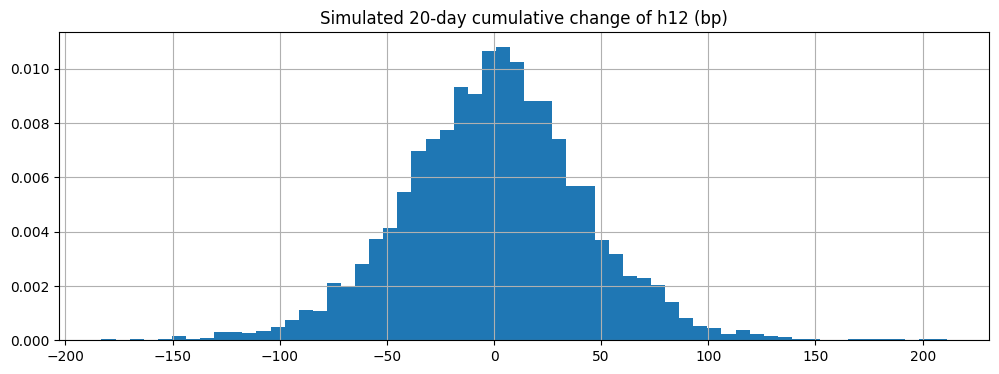

Quantiles (bp): [-105.94  -69.19    0.73   69.66  103.27]


In [ ]:
# [11] Probability queries: cumulative move distribution and event probabilities

def cumulative_change(sim_dF, col_name, H=20):
    cols = pca["cols"]
    j = cols.index(col_name)
    cum = sim_dF[:, :H, j].sum(axis=1)
    return cum

def prob_exceed(sim_dF, col_name, H=20, threshold_bp=10.0):
    cum = cumulative_change(sim_dF, col_name, H=H)
    thr = threshold_bp / 1e4
    p = np.mean(np.abs(cum) > thr)
    return p, cum

p20, cum20 = prob_exceed(sim["dF_sim"], "h12", H=20, threshold_bp=10.0)
print("P(|20d cumulative Δh12| > 10bp) =", p20)

plt.hist(cum20*1e4, bins=60, density=True)
plt.title("Simulated 20-day cumulative change of h12 (bp)")
plt.show()

print("Quantiles (bp):", (np.quantile(cum20, [0.01,0.05,0.5,0.95,0.99])*1e4).round(2))


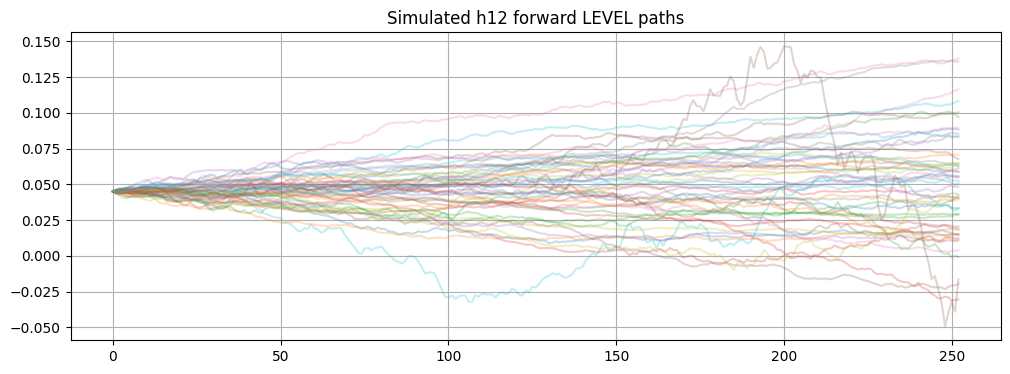

In [ ]:
# [12] Reconstruct forward LEVEL paths from ΔF simulations (optional but often needed)
# Anchor at the last observed level.

def reconstruct_levels(fwds_horizon: pd.DataFrame, sim_dF: np.ndarray, anchor_date=None):
    cols = [c for c in pca["cols"] if c in fwds_horizon.columns]
    if anchor_date is None:
        anchor_date = Y.index[-1]
    F0 = fwds_horizon.loc[anchor_date, cols].astype(float).values

    n_sims, n_steps, m = sim_dF.shape
    F = np.zeros((n_sims, n_steps+1, m))
    F[:, 0, :] = F0
    F[:, 1:, :] = F0 + np.cumsum(sim_dF, axis=1)
    return cols, F

cols, Fpaths = reconstruct_levels(fwds_horizon, sim["dF_sim"], anchor_date=Y.index[-1])

# Plot a few simulated paths for h12 level
j = cols.index("h12")
plt.figure(figsize=(12,4))
for k in range(50):
    plt.plot(Fpaths[k, :, j], alpha=0.25)
plt.title("Simulated h12 forward LEVEL paths")
plt.show()


First 20 stds: [0.00064926 0.00066182 0.00067572 0.00067097 0.00067781 0.00068012
 0.00067273 0.0006868  0.00067962 0.00068964 0.00068802 0.00069868
 0.00068943 0.00069827 0.00070847 0.00071107 0.00070613 0.00070892
 0.00071825 0.00070963]
Std 140..160: [0.00091506 0.0008847  0.00092711 0.00096107 0.00097862 0.00088654
 0.00089939 0.00093203 0.0010004  0.00094239 0.00093745 0.00092105
 0.00092683 0.00095176 0.00092901 0.00090003 0.00098176 0.00094343
 0.00095461 0.00092801 0.00097785]
Min std overall: 0.0006492581627190145


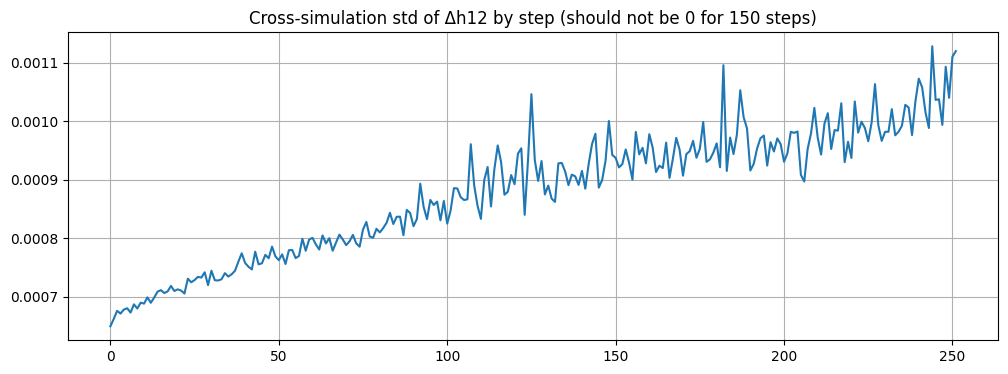

In [ ]:
# [17] DIAGNOSTIC: check if your simulated Δh12 is exactly 0 for the first ~150 steps
# Run this right after you create `sim` (or after you re-run simulation below).

col_idx = pca["cols"].index("h12")

# cross-sim std per time step (should NOT be exactly 0 for long stretches)
std_by_t = sim["dF_sim"][:, :, col_idx].std(axis=0)

print("First 20 stds:", std_by_t[:20])
print("Std 140..160:", std_by_t[140:161])
print("Min std overall:", std_by_t.min())

plt.plot(std_by_t)
plt.title("Cross-simulation std of Δh12 by step (should not be 0 for 150 steps)")
plt.show()


In [ ]:
# [13] Model validation tests (persistence + heteroskedasticity + probability calibration)
# Persistence captured: d_resid (ARMA residuals) should be closer to 0 than d_raw
# Heteroskedasticity captured: standardized residuals should have weak ARCH effects
# Probability calibration: PIT uniformity for standardized residuals under chosen innovation dist

def pit_test_for_factor(c):
    arma_res = arma_fits[c]["res"]
    resid = arma_res.resid.values
    resid = resid[np.isfinite(resid)]

    garch_res = garch_fits[c]["chosen"]
    cond_vol = np.asarray(garch_res.conditional_volatility, float)
    rr = resid[-len(cond_vol):]
    zstd = rr / (cond_vol + 1e-12)

    dist = garch_res.model.distribution.name.lower()
    if dist.startswith("student"):
        nu = float(garch_res.params["nu"])
        # map unit-variance standardized residuals to standard t quantiles:
        u = stats.t.cdf(zstd * np.sqrt(nu/(nu-2.0)), df=nu)
    else:
        u = stats.norm.cdf(zstd)

    ks = stats.kstest(u, "uniform")
    return zstd, u, ks

report = []
for c in pca["Z"].columns:
    z = pca["Z"][c].values
    d_raw = d_est[c]

    arma_resid = arma_fits[c]["res"].resid.values
    arma_resid = arma_resid[np.isfinite(arma_resid)]
    try:
        d_res, _ = local_whittle_d(arma_resid)
    except Exception:
        d_res = np.nan

    arch_p = het_arch(arma_resid, nlags=10)[1]

    zstd, u, ks = pit_test_for_factor(c)
    arch_p_std = het_arch(zstd, nlags=10)[1]

    report.append({
        "factor": c,
        "d_raw": d_raw,
        "d_resid": d_res,
        "ARCH_p_resid": float(arch_p),
        "ARCH_p_std": float(arch_p_std),
        "PIT_KS_stat": float(ks.statistic),
        "PIT_KS_p": float(ks.pvalue),
        "garch_dist": garch_fits[c]["chosen"].model.distribution.name
    })

report_df = pd.DataFrame(report)
report_df


,factor,d_raw,d_resid,ARCH_p_resid,ARCH_p_std,PIT_KS_stat,PIT_KS_p,garch_dist
0,PC1,-0.285312,-0.043906,2.492140e-11,0.998659,0.070963,2.618568e-17,Standardized Student's t
1,PC2,-0.276797,-0.003203,9.138052e-46,0.242297,0.056914,2.769937e-11,Standardized Student's t
2,PC3,-0.107734,-0.038281,9.999998e-01,0.999999,0.141162,2.050519e-67,Standardized Student's t


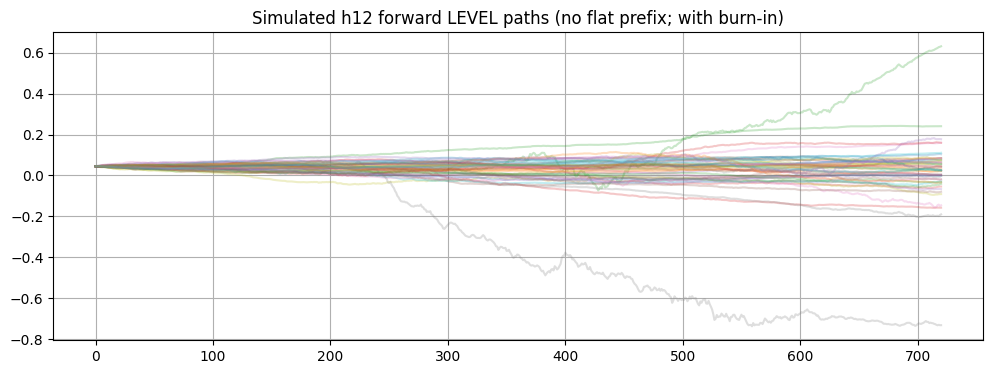

Std 0..20: [0.00066227 0.00067144 0.00066859 0.00067884 0.00067005 0.0006753
 0.00068901 0.00069625 0.00068236 0.00069097 0.00069691 0.00069096
 0.00069986 0.00069993 0.0006918  0.00070098 0.00070692 0.00069714
 0.00070215 0.00071004 0.000722  ]


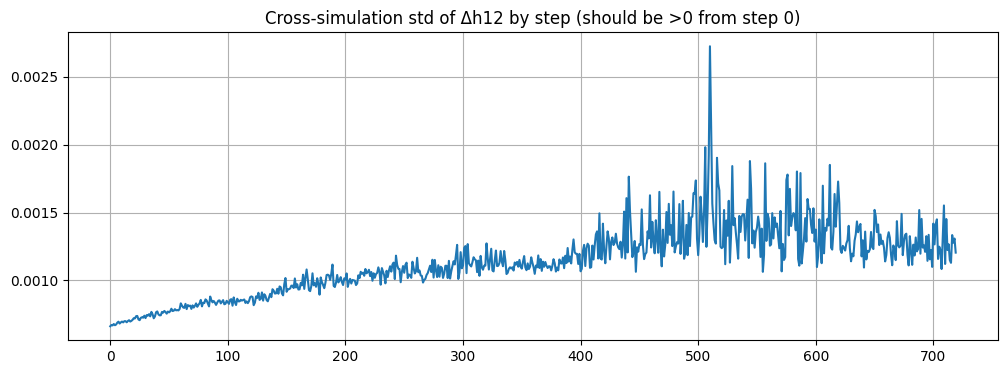

In [ ]:
# [20] Reconstruct LEVEL paths and plot h12
cols, Fpaths = reconstruct_levels(fwds_horizon, sim["dF_sim"], anchor_date=Y.index[-1])
j = cols.index("h12")

plt.figure(figsize=(12,4))
for k in range(50):
    plt.plot(Fpaths[k, :, j], alpha=0.25)
plt.title("Simulated h12 forward LEVEL paths (no flat prefix; with burn-in)")
plt.grid(True)
plt.show()

# Run the diagnostic again
col_idx = pca["cols"].index("h12")
std_by_t = sim["dF_sim"][:, :, col_idx].std(axis=0)
print("Std 0..20:", std_by_t[:21])
plt.plot(std_by_t)
plt.title("Cross-simulation std of Δh12 by step (should be >0 from step 0)")
plt.show()


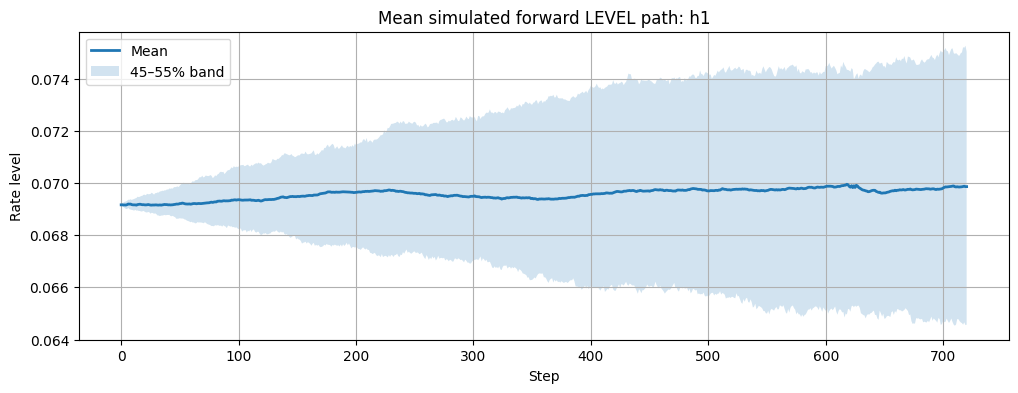

In [ ]:
# [21] Plot the mean simulated forward LEVEL (and optional bands) for a chosen horizon, e.g. h12
# Requires: Fpaths from [20] (shape: n_sims x (n_steps+1) x m) and cols list.

import numpy as np
import matplotlib.pyplot as plt

def plot_mean_level(Fpaths, cols, col_name="h1", bands=(0.05, 0.95)):
    j = cols.index(col_name)

    mean_path = Fpaths[:, :, j].mean(axis=0)
    lo = np.quantile(Fpaths[:, :, j], bands[0], axis=0)
    hi = np.quantile(Fpaths[:, :, j], bands[1], axis=0)

    x = np.arange(Fpaths.shape[1])

    plt.figure(figsize=(12,4))
    plt.plot(x, mean_path, linewidth=2, label="Mean")
    plt.fill_between(x, lo, hi, alpha=0.2, label=f"{int(bands[0]*100)}–{int(bands[1]*100)}% band")
    plt.title(f"Mean simulated forward LEVEL path: {col_name}")
    plt.xlabel("Step")
    plt.ylabel("Rate level")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_mean_level(Fpaths, cols, col_name="h1", bands=(0.45, 0.55))


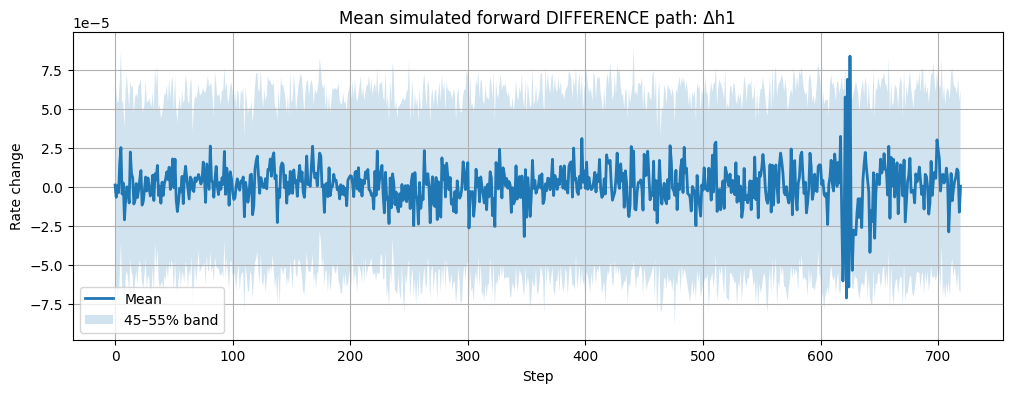

In [ ]:
# [22] Plot the mean simulated forward DIFFERENCE (ΔF) path for a chosen horizon, e.g. h12
# Requires: sim["dF_sim"] and pca["cols"]

def plot_mean_diff(sim_dF, cols, col_name="h1", bands=(0.05, 0.95)):
    j = cols.index(col_name)

    mean_path = sim_dF[:, :, j].mean(axis=0)
    lo = np.quantile(sim_dF[:, :, j], bands[0], axis=0)
    hi = np.quantile(sim_dF[:, :, j], bands[1], axis=0)

    x = np.arange(sim_dF.shape[1])

    plt.figure(figsize=(12,4))
    plt.plot(x, mean_path, linewidth=2, label="Mean")
    plt.fill_between(x, lo, hi, alpha=0.2, label=f"{int(bands[0]*100)}–{int(bands[1]*100)}% band")
    plt.title(f"Mean simulated forward DIFFERENCE path: Δ{col_name}")
    plt.xlabel("Step")
    plt.ylabel("Rate change")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_mean_diff(sim["dF_sim"], pca["cols"], col_name="h1", bands=(0.45, 0.55))


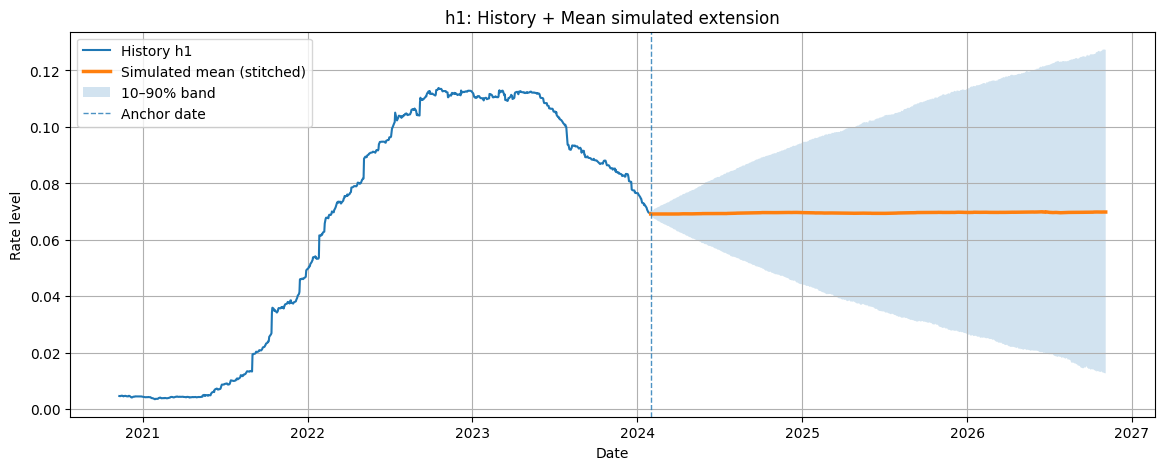

In [ ]:
# [23] Stitch historical series with the MEAN simulated forward LEVEL path (plus optional bands)
# Requires:
#   - fwds_horizon: historical forward LEVEL panel with columns h1..h12
#   - sim["dF_sim"]: simulated forward DIFFERENCES (n_sims x n_steps x m)
#   - pca["cols"]: column order matching sim["dF_sim"]
#   - Y.index[-1] is the last date used for differences; we'll anchor simulation at that date.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def stitch_history_with_mean_sim_level(
    fwds_horizon: pd.DataFrame,
    sim_dF: np.ndarray,
    cols_order: list,
    col_name: str = "h12",
    anchor_date=None,
    freq="B",                 # business day index for simulation
    bands=(0.05, 0.95),       # quantile band for uncertainty
    hist_window=None          # e.g., 800 to show last 800 points; None shows full history
):
    fwds_horizon = fwds_horizon.copy()
    fwds_horizon[col_name] = pd.to_numeric(fwds_horizon[col_name], errors="coerce")

    if anchor_date is None:
        # anchor at the last date in fwds_horizon that also exists in Y (typical)
        anchor_date = fwds_horizon.index.max()

    if anchor_date not in fwds_horizon.index:
        raise ValueError("anchor_date not found in fwds_horizon index.")

    j = cols_order.index(col_name)

    # Build simulated LEVEL paths starting from historical anchor
    F0 = float(fwds_horizon.loc[anchor_date, col_name])
    if not np.isfinite(F0):
        raise ValueError(f"Anchor level for {col_name} is NaN at {anchor_date}.")

    # levels: F0 + cumulative sum of diffs
    cum = np.cumsum(sim_dF[:, :, j], axis=1)  # (n_sims x n_steps)
    levels = F0 + np.concatenate([np.zeros((cum.shape[0], 1)), cum], axis=1)  # include step 0

    mean_path = levels.mean(axis=0)
    lo = np.quantile(levels, bands[0], axis=0)
    hi = np.quantile(levels, bands[1], axis=0)

    # Build future date index (step 0 corresponds to anchor_date)
    n_steps = sim_dF.shape[1]
    future_idx = pd.date_range(anchor_date, periods=n_steps+1, freq=freq)

    sim_mean = pd.Series(mean_path, index=future_idx, name="SimMean")
    sim_lo = pd.Series(lo, index=future_idx, name="SimLo")
    sim_hi = pd.Series(hi, index=future_idx, name="SimHi")

    # Historical series (optionally windowed)
    hist = fwds_horizon[col_name].dropna().sort_index()
    if hist_window is not None:
        hist = hist.iloc[-hist_window:]

    # Plot
    plt.figure(figsize=(14,5))
    plt.plot(hist.index, hist.values, linewidth=1.5, label=f"History {col_name}")
    plt.plot(sim_mean.index, sim_mean.values, linewidth=2.5, label="Simulated mean (stitched)")
    plt.fill_between(sim_mean.index, sim_lo.values, sim_hi.values, alpha=0.2,
                     label=f"{int(bands[0]*100)}–{int(bands[1]*100)}% band")
    plt.axvline(anchor_date, linestyle="--", linewidth=1.0, alpha=0.8, label="Anchor date")
    plt.title(f"{col_name}: History + Mean simulated extension")
    plt.xlabel("Date")
    plt.ylabel("Rate level")
    plt.grid(True)
    plt.legend()
    plt.show()

    return {"hist": hist, "sim_mean": sim_mean, "sim_lo": sim_lo, "sim_hi": sim_hi}

# Example: stitch h12 with 1y (252 business days) simulated mean
out = stitch_history_with_mean_sim_level(
    fwds_horizon=fwds_horizon,
    sim_dF=sim["dF_sim"],
    cols_order=pca["cols"],
    col_name="h1",
    anchor_date=Y.index[-1],   # anchor where differences end
    freq="B",
    bands=(0.1, 0.90),
    hist_window=800
)


In [ ]:
# [25] Quantify downside probability from the simulation (what you "feel" should be higher)
def downside_prob_levels(Fpaths, cols, col_name="h1", horizon_steps=252):
    j = cols.index(col_name)
    F0 = Fpaths[:, 0, j]
    FH = Fpaths[:, horizon_steps, j]
    p_down = np.mean(FH < F0)
    return p_down, FH - F0

p_down, dF = downside_prob_levels(Fpaths, cols, col_name="h1", horizon_steps=252)
print("P(F_T < F0) at 1y horizon =", p_down)
print("Quantiles of (F_T - F0) in bp:", (np.quantile(dF, [0.01,0.05,0.5,0.95,0.99])*1e4).round(2))


P(F_T < F0) at 1y horizon = 0.4846
Quantiles of (F_T - F0) in bp: [-595.24 -351.57    7.44  353.07  607.36]


In [ ]:
# [26] Refit GARCH with skewed-t available as an option (choose among normal, t, skewt by AIC)
# Requires: arch installed (you already have it)

def fit_garch_choose3(resid):
    resid = np.asarray(resid, float)
    resid = resid[np.isfinite(resid)]
    resid = resid - resid.mean()

    candidates = {}

    for dist in ["normal", "t", "skewt"]:
        try:
            m = arch_model(resid, mean="Zero", vol="GARCH", p=1, q=1, dist=dist)
            r = m.fit(disp="off")
            candidates[dist] = r
        except Exception:
            continue

    if not candidates:
        raise RuntimeError("No GARCH model could be fit. Check residual series.")

    chosen_dist = min(candidates.keys(), key=lambda k: candidates[k].aic)
    return {"chosen": candidates[chosen_dist], "all": candidates}

# Refit GARCH for each factor residual
garch_fits = {}
for c, fit in arma_fits.items():
    resid = fit["res"].resid.values
    gg = fit_garch_choose3(resid)
    garch_fits[c] = gg
    ch = gg["chosen"]
    print(f"{c}: chosen={ch.model.distribution.name}, AIC={ch.aic:.1f}, params={list(ch.params.index)}")


PC1: chosen=Standardized Student's t, AIC=15859.0, params=['omega', 'alpha[1]', 'beta[1]', 'nu']
PC2: chosen=Standardized Student's t, AIC=11166.5, params=['omega', 'alpha[1]', 'beta[1]', 'nu']
PC3: chosen=Standardized Student's t, AIC=-4282.5, params=['omega', 'alpha[1]', 'beta[1]', 'nu']


In [ ]:
# [27] Simulate GARCH innovations using the last estimated conditional volatility as the initial state
def simulate_garch_path_from_last(garch_res, n_steps, rng):
    params = garch_res.params
    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    beta  = float(params["beta[1]"])
    dist = garch_res.model.distribution.name.lower()

    nu = float(params["nu"]) if "nu" in params.index else None
    lam = float(params["lambda"]) if "lambda" in params.index else None  # skewness parameter for skewt

    # initialize at the last filtered variance (conditional_volatility^2)
    cv = np.asarray(garch_res.conditional_volatility, float)
    h0 = float(cv[-1]**2) if len(cv) else float(np.var(garch_res.resid))
    h0 = max(h0, 1e-12)

    h = np.zeros(n_steps)
    eps = np.zeros(n_steps)
    h[0] = h0

    for t in range(n_steps):
        if t > 0:
            h[t] = omega + alpha*(eps[t-1]**2) + beta*h[t-1]
            h[t] = max(h[t], 1e-12)

        if dist.startswith("student"):
            z = rng.standard_t(df=nu)
            z = z * np.sqrt((nu - 2.0)/nu)  # unit variance
        elif dist.startswith("skew"):
            # arch skewt is Hansen's skewed-t. We'll sample by using arch's distribution object directly.
            # This avoids implementing skewed-t sampling manually.
            z = garch_res.model.distribution.simulate(params).rvs(1, random_state=rng)[0]
            # distribution.simulate returns already standardized for the model
        else:
            z = rng.standard_normal()

        eps[t] = np.sqrt(h[t]) * z

    return eps, h


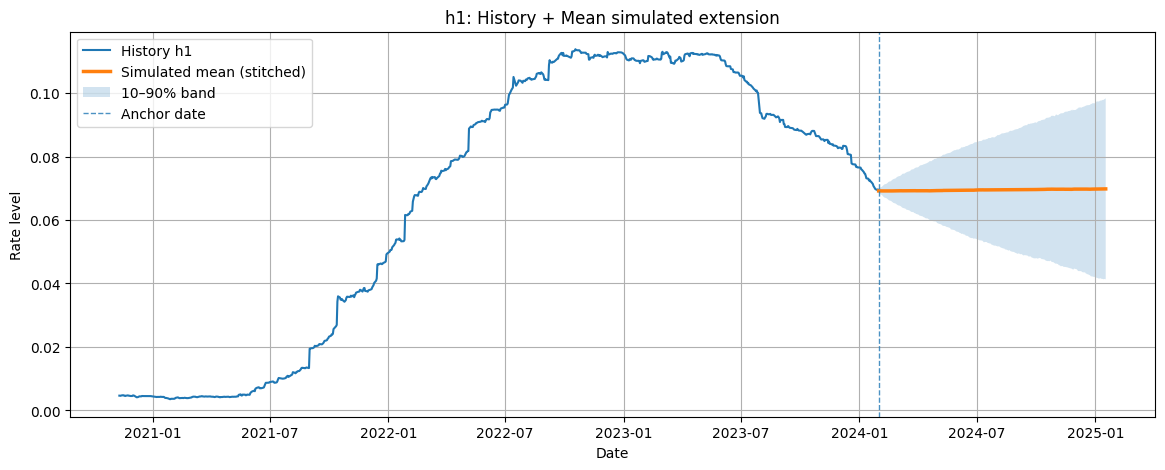

P(F_T < F0) at 1y horizon = 0.4848
Quantiles of (F_T - F0) in bp: [-728.46 -409.24    8.9   398.06  727.96]


In [ ]:
# [28] Re-run simulation using skew-t (if selected) and last-state initialization

def simulate_pca_arfima_garch_with_burnin(pca, arma_fits, garch_fits, d_est,
                                         n_steps=252, burnin=300, n_sims=2000,
                                         seed=42, n_lags_inv=200):
    rng = np.random.default_rng(seed)

    W = pca["W"]
    mu = pca["mu"]
    scale = pca["scale"]
    r = W.shape[1]
    m = W.shape[0]

    E = pca["E"].values
    Sigma_e = np.cov(E.T, ddof=1)

    total = n_steps + burnin
    Z_sim = np.zeros((n_sims, n_steps, r))
    dF_sim = np.zeros((n_sims, n_steps, m))

    for k, c in enumerate(pca["Z"].columns):
        d = float(d_est[c])
        arma_res = arma_fits[c]["res"]
        garch_res = garch_fits[c]["chosen"]

        for s in range(n_sims):
            eps, _h = simulate_garch_path_from_last(garch_res, n_steps=total, rng=rng)
            z_fd = arma_simulate_from_fit(arma_res, eps=eps)
            z = fracintegrate_series(z_fd, d=d, n_lags=n_lags_inv)
            Z_sim[s, :, k] = z[burnin:burnin+n_steps]

    for s in range(n_sims):
        Xhat = Z_sim[s] @ W.T
        e = rng.multivariate_normal(mean=np.zeros(m), cov=Sigma_e, size=n_steps)
        Xcs = Xhat + e
        dF_sim[s] = mu + scale * Xcs

    return {"Z_sim": Z_sim, "dF_sim": dF_sim, "Sigma_e": Sigma_e}

sim = simulate_pca_arfima_garch_with_burnin(
    pca=pca, arma_fits=arma_fits, garch_fits=garch_fits, d_est=d_est,
    n_steps=252, burnin=300, n_sims=5000, seed=RNG_SEED, n_lags_inv=200
)

cols, Fpaths = reconstruct_levels(fwds_horizon, sim["dF_sim"], anchor_date=Y.index[-1])

# Stitch plot again
out = stitch_history_with_mean_sim_level(
    fwds_horizon=fwds_horizon,
    sim_dF=sim["dF_sim"],
    cols_order=pca["cols"],
    col_name="h1",
    anchor_date=Y.index[-1],
    freq="B",
    bands=(0.10, 0.90),
    hist_window=800
)

# Downside probability check
p_down, dF = downside_prob_levels(Fpaths, cols, col_name="h1", horizon_steps=252)
print("P(F_T < F0) at 1y horizon =", p_down)
print("Quantiles of (F_T - F0) in bp:", (np.quantile(dF, [0.01,0.05,0.5,0.95,0.99])*1e4).round(2))


In [ ]:
# [29] Fit a mean-reversion drift on PCA factors: Δz_t = c - kappa z_{t-1} + u_t
# This is the minimal "rates have tendency to revert" mechanism that creates higher downside probability
# when z is currently high.

import statsmodels.api as sm

def fit_drift_ou_discrete(z: pd.Series):
    """
    Fit: Δz_t = c - kappa z_{t-1} + u_t
    Returns c, kappa, residual series u_t aligned to t.
    """
    z = z.dropna()
    dz = z.diff().dropna()
    z_lag = z.shift(1).loc[dz.index]

    X = pd.DataFrame({"const": 1.0, "z_lag": z_lag})
    y = dz
    res = sm.OLS(y, X, missing="drop").fit()
    c = float(res.params["const"])
    kappa = float(-res.params["z_lag"])  # because model is c - kappa z_{t-1}
    u = res.resid
    return {"c": c, "kappa": kappa, "u": u, "ols": res}

drift_fits = {}
for c in pca["Z"].columns:
    drift_fits[c] = fit_drift_ou_discrete(pca["Z"][c])
    print(c, "c=", drift_fits[c]["c"], "kappa=", drift_fits[c]["kappa"])


PC1 c= 4.9782393305139276e-05 kappa= 0.7803136596962466
PC2 c= -4.727458673504898e-05 kappa= 1.03288670109042
PC3 c= -7.119581693728922e-07 kappa= 1.0240382125891465


In [ ]:
# [30] Fit ARFIMA(approx) + GARCH on the drift residual u_t (NOT on raw factors)
# This isolates long-memory/heteroskedasticity in the innovation, while drift handles directional tendency.

# Rebuild arma_fits_u and garch_fits_u based on u_t
arma_fits_u = {}
garch_fits_u = {}
d_est_u = {}

for c in pca["Z"].columns:
    u = drift_fits[c]["u"].values

    # estimate long memory on u_t
    d_hat, _ = local_whittle_d(u)
    d_est_u[c] = d_hat

    # ARMA on frac-diff(u)
    arma_fits_u[c] = fit_arma_on_fracdiff(u, d=d_hat, p_max=3, q_max=3, n_lags_fd=150)

    # GARCH choose (normal/t/skewt) on ARMA residuals
    resid = arma_fits_u[c]["res"].resid.values
    garch_fits_u[c] = fit_garch_choose3(resid)

    ch = garch_fits_u[c]["chosen"]
    print(f"{c}: d_u={d_hat:.3f}, ARMA({arma_fits_u[c]['p']},{arma_fits_u[c]['q']}), "
          f"GARCH={ch.model.distribution.name}, AIC={ch.aic:.1f}")


/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11

PC1: d_u=-0.283, ARMA(3,1), GARCH=Standardized Student's t, AIC=15859.8


/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11

PC2: d_u=-0.276, ARMA(3,1), GARCH=Standardized Student's t, AIC=11161.6


/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11

PC3: d_u=-0.108, ARMA(1,3), GARCH=Standardized Student's t, AIC=-4280.4


/Users/josemelo/Desktop/dev/notebook/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# [31] Simulate factors WITH drift:
# z_{t} = z_{t-1} + (c - kappa z_{t-1}) + u_t
# where u_t is ARFIMA+GARCH simulated from the fitted residual model.

def simulate_factor_with_drift(c_name, n_steps, burnin, seed):
    rng = np.random.default_rng(seed)

    # drift params
    c0 = drift_fits[c_name]["c"]
    kappa = drift_fits[c_name]["kappa"]

    # innovation model params
    d = float(d_est_u[c_name])
    arma_res = arma_fits_u[c_name]["res"]
    garch_res = garch_fits_u[c_name]["chosen"]

    total = n_steps + burnin

    # simulate u_t
    eps, _h = simulate_garch_path_from_last(garch_res, n_steps=total, rng=rng)
    u_fd = arma_simulate_from_fit(arma_res, eps=eps)
    u = fracintegrate_series(u_fd, d=d, n_lags=200)

    # now simulate z with drift recursion
    z = np.zeros(total)
    # initialize at last observed factor level (conditioning on current state)
    z0 = float(pca["Z"][c_name].dropna().iloc[-1])
    z[0] = z0

    for t in range(1, total):
        drift = c0 - kappa * z[t-1]
        z[t] = z[t-1] + drift + u[t]

    return z[burnin:burnin+n_steps]

def simulate_all_factors_with_drift(n_steps=252, burnin=300, n_sims=5000, seed=42):
    rng_master = np.random.default_rng(seed)
    factor_names = list(pca["Z"].columns)
    r = len(factor_names)

    Z_sim = np.zeros((n_sims, n_steps, r))
    for s in range(n_sims):
        # use different seeds per sim for reproducibility
        base = int(rng_master.integers(0, 2**31-1))
        for k, cname in enumerate(factor_names):
            Z_sim[s, :, k] = simulate_factor_with_drift(cname, n_steps, burnin, seed=base + 1000*k)
    return Z_sim

Z_sim_drift = simulate_all_factors_with_drift(n_steps=252, show=False) if False else simulate_all_factors_with_drift(n_steps=252, burnin=300, n_sims=5000, seed=RNG_SEED)
Z_sim_drift.shape


(5000, 252, 3)

In [ ]:
# [32] Reconstruct ΔF and LEVELS using the drifted factor simulation
def reconstruct_dF_from_factors(pca, Z_sim, seed=42):
    rng = np.random.default_rng(seed)
    W = pca["W"]
    mu = pca["mu"]
    scale = pca["scale"]
    E = pca["E"].values
    Sigma_e = np.cov(E.T, ddof=1)

    n_sims, n_steps, r = Z_sim.shape
    m = W.shape[0]

    dF_sim = np.zeros((n_sims, n_steps, m))
    for s in range(n_sims):
        Xhat = Z_sim[s] @ W.T
        e = rng.multivariate_normal(mean=np.zeros(m), cov=Sigma_e, size=n_steps)
        Xcs = Xhat + e
        dF_sim[s] = mu + scale * Xcs
    return dF_sim

dF_sim_drift = reconstruct_dF_from_factors(pca, Z_sim_drift, seed=RNG_SEED)

cols, Fpaths_drift = reconstruct_levels(fwds_horizon, dF_sim_drift, anchor_date=Y.index[-1])


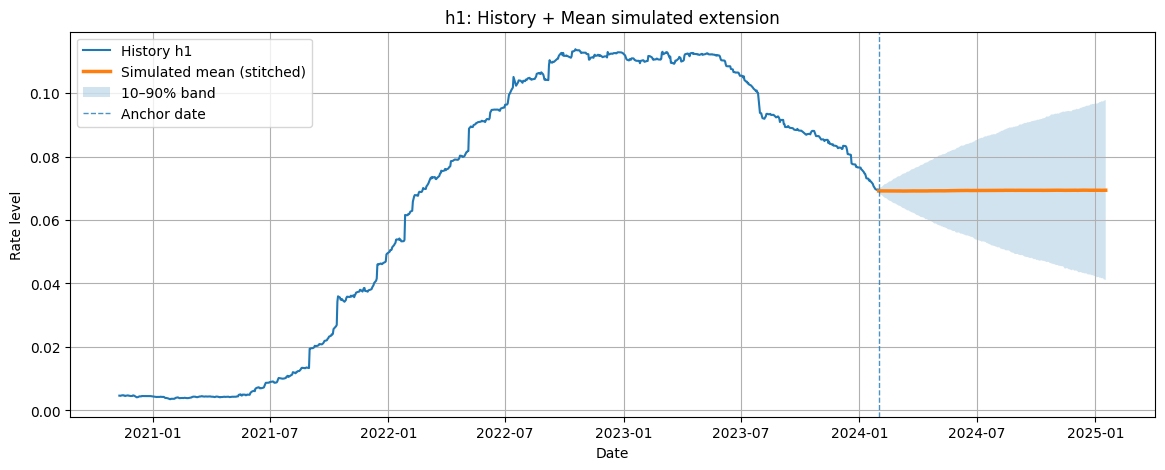

P(F_T < F0) at 1y horizon = 0.4946
Quantiles of (F_T - F0) in bp: [-784.96 -406.32    2.4   406.51  810.39]


In [ ]:
# [33] Stitch mean + check downside probability again (this should move away from 0.5 if kappa>0 and z0 is high)
out = stitch_history_with_mean_sim_level(
    fwds_horizon=fwds_horizon,
    sim_dF=dF_sim_drift,
    cols_order=pca["cols"],
    col_name="h1",
    anchor_date=Y.index[-1],
    freq="B",
    bands=(0.10, 0.90),
    hist_window=800
)

p_down, dF = downside_prob_levels(Fpaths_drift, cols, col_name="h1", horizon_steps=252)
print("P(F_T < F0) at 1y horizon =", p_down)
print("Quantiles of (F_T - F0) in bp:", (np.quantile(dF, [0.01,0.05,0.5,0.95,0.99])*1e4).round(2))


In [ ]:
# [34] Extract ARMA coefficients from SARIMAX fit robustly
def extract_arma_params(arma_res):
    p = arma_res.model_orders["ar"]
    q = arma_res.model_orders["ma"]
    params = arma_res.params

    ar = np.zeros(p)
    ma = np.zeros(q)

    for i in range(p):
        key = f"ar.L{i+1}"
        if key in params.index:
            ar[i] = float(params[key])
    for j in range(q):
        key = f"ma.L{j+1}"
        if key in params.index:
            ma[j] = float(params[key])

    # positional fallback if names missing
    if p > 0 and np.allclose(ar, 0):
        ar = params.values[:p]
    if q > 0 and np.allclose(ma, 0):
        ma = params.values[p:p+q]

    return ar, ma


In [ ]:
# [35] Conditional ARMA simulation: start from last observed y_fd and last residuals
def arma_simulate_conditional(ar, ma, y_hist, e_hist, e_future):
    """
    Simulate future y given:
      y_t = sum_i ar[i]*y_{t-i} + e_t + sum_j ma[j]*e_{t-j}
    with history for y and e.
    """
    ar = np.asarray(ar, float)
    ma = np.asarray(ma, float)
    p, q = len(ar), len(ma)

    y_hist = list(np.asarray(y_hist, float).tolist())  # last p values (oldest->newest)
    e_hist = list(np.asarray(e_hist, float).tolist())  # last q values (oldest->newest)

    y_out = np.zeros(len(e_future))

    for t in range(len(e_future)):
        e_t = float(e_future[t])

        ar_term = 0.0
        for i in range(1, p+1):
            ar_term += ar[i-1] * y_hist[-i]

        ma_term = 0.0
        for j in range(1, q+1):
            ma_term += ma[j-1] * e_hist[-j]

        y_t = ar_term + e_t + ma_term
        y_out[t] = y_t

        # update histories
        if p > 0:
            y_hist.append(y_t)
            y_hist = y_hist[-p:]
        if q > 0:
            e_hist.append(e_t)
            e_hist = e_hist[-q:]

    return y_out


In [ ]:
# [36] Build the fractionally-differenced factor series z_fd and aligned ARMA residuals
# This provides the "current state" for conditional simulation.

def build_fd_and_resid_for_factor(z_series, d, arma_fit, n_lags_fd=150):
    """
    Returns:
      z_fd: pd.Series fractionally differenced z
      resid: pd.Series ARMA residuals on z_fd (aligned)
    """
    z = z_series.dropna().astype(float)
    z_arr = z.values - z.values.mean()

    z_fd_arr = fracdiff_series(z_arr, d=d, n_lags=n_lags_fd)
    z_fd = pd.Series(z_fd_arr, index=z.index).dropna()

    # Fit result stored in arma_fit already uses its own z_fd. We re-align residuals to z_fd index.
    arma_res = arma_fit["res"]
    resid = pd.Series(arma_res.resid, index=arma_res.model.data.row_labels)

    # Ensure alignment
    common = z_fd.index.intersection(resid.index)
    return z_fd.loc[common], resid.loc[common]


In [ ]:
# [37] Conditional simulation of one PCA factor (ARFIMA approx + GARCH) starting from last state
def simulate_factor_conditional(c_name, n_steps=252, seed=42, n_lags_fd=150, n_lags_inv=200):
    rng = np.random.default_rng(seed)

    # model components
    d = float(d_est[c_name])
    arma_res = arma_fits[c_name]["res"]
    garch_res = garch_fits[c_name]["chosen"]

    # get z_fd history and ARMA residual history aligned
    z_series = pca["Z"][c_name]
    z_fd, resid = build_fd_and_resid_for_factor(z_series, d=d, arma_fit=arma_fits[c_name], n_lags_fd=n_lags_fd)

    # ARMA params
    ar, ma = extract_arma_params(arma_res)
    p, q = len(ar), len(ma)

    # histories: last p values of z_fd and last q residuals
    y_hist = z_fd.values[-p:] if p > 0 else np.array([])
    e_hist = resid.values[-q:] if q > 0 else np.array([])

    # simulate future innovations e_t from GARCH conditional on last volatility state
    e_future, _h = simulate_garch_path_from_last(garch_res, n_steps=n_steps, rng=rng)

    # simulate future z_fd conditionally
    z_fd_future = arma_simulate_conditional(ar, ma, y_hist=y_hist, e_hist=e_hist, e_future=e_future)

    # now invert fractional differencing to get z:
    # we must append to past z_fd to make inversion coherent
    z_fd_full = np.concatenate([z_fd.values, z_fd_future])
    z_full = fracintegrate_series(z_fd_full, d=d, n_lags=n_lags_inv)

    # take only simulated tail corresponding to the future horizon
    z_sim = z_full[-n_steps:]
    return z_sim


In [ ]:
# [40] Robust conditional ARMA simulator (pads histories if too short)
def arma_simulate_conditional(ar, ma, y_hist, e_hist, e_future):
    ar = np.asarray(ar, float)
    ma = np.asarray(ma, float)
    p, q = len(ar), len(ma)

    y_hist = np.asarray(y_hist, float).copy()
    e_hist = np.asarray(e_hist, float).copy()

    # Pad histories if too short
    if p > 0 and y_hist.size < p:
        y_hist = np.concatenate([np.zeros(p - y_hist.size), y_hist])
    if q > 0 and e_hist.size < q:
        e_hist = np.concatenate([np.zeros(q - e_hist.size), e_hist])

    y_out = np.zeros(len(e_future))

    for t in range(len(e_future)):
        e_t = float(e_future[t])

        ar_term = 0.0
        if p > 0:
            for i in range(1, p+1):
                ar_term += ar[i-1] * y_hist[-i]

        ma_term = 0.0
        if q > 0:
            for j in range(1, q+1):
                ma_term += ma[j-1] * e_hist[-j]

        y_t = ar_term + e_t + ma_term
        y_out[t] = y_t

        # update histories
        if p > 0:
            y_hist = np.append(y_hist, y_t)[-p:]
        if q > 0:
            e_hist = np.append(e_hist, e_t)[-q:]

    return y_out


In [ ]:
# [41] Make the "fd + resid alignment" function always return enough history by loosening alignment logic
def build_fd_and_resid_for_factor(z_series, d, arma_fit, n_lags_fd=150):
    """
    Returns z_fd and resid on the SAME INDEX, with maximal overlap.
    If overlap is too small, it falls back to using the ARMA fit's internal z_fd index.
    """
    z = z_series.dropna().astype(float)
    z_arr = z.values - z.values.mean()

    z_fd_arr = fracdiff_series(z_arr, d=d, n_lags=n_lags_fd)
    z_fd_all = pd.Series(z_fd_arr, index=z.index).dropna()

    arma_res = arma_fit["res"]
    resid_all = pd.Series(arma_res.resid, index=arma_res.model.data.row_labels).dropna()

    common = z_fd_all.index.intersection(resid_all.index)
    if len(common) >= max(50, arma_fit["p"] + arma_fit["q"] + 5):
        z_fd = z_fd_all.loc[common]
        resid = resid_all.loc[common]
    else:
        # fallback: trust the ARMA model's own index and just use its z_fd / resid
        z_fd = arma_fit["z_fd"].copy()
        resid = resid_all.reindex(z_fd.index).dropna()
        # if resid is still too short, pad later in arma_simulate_conditional

    return z_fd, resid


In [ ]:
# [42] Patch simulate_factor_conditional to use the padded histories
def simulate_factor_conditional(c_name, n_steps=252, seed=42, n_lags_fd=150, n_lags_inv=200):
    rng = np.random.default_rng(seed)

    d = float(d_est[c_name])
    arma_res = arma_fits[c_name]["res"]
    garch_res = garch_fits[c_name]["chosen"]

    ar, ma = extract_arma_params(arma_res)
    p, q = len(ar), len(ma)

    z_series = pca["Z"][c_name]
    z_fd, resid = build_fd_and_resid_for_factor(z_series, d=d, arma_fit=arma_fits[c_name], n_lags_fd=n_lags_fd)

    y_hist = z_fd.values[-p:] if p > 0 else np.array([])
    e_hist = resid.values[-q:] if q > 0 else np.array([])

    # simulate future innovations from GARCH (conditional on last vol state)
    e_future, _h = simulate_garch_path_from_last(garch_res, n_steps=n_steps, rng=rng)

    # simulate future z_fd conditionally (now robust to short histories)
    z_fd_future = arma_simulate_conditional(ar, ma, y_hist=y_hist, e_hist=e_hist, e_future=e_future)

    # invert fractional differencing with history
    z_fd_full = np.concatenate([z_fd.values, z_fd_future])
    z_full = fracintegrate_series(z_fd_full, d=d, n_lags=n_lags_inv)

    z_sim = z_full[-n_steps:]
    return z_sim


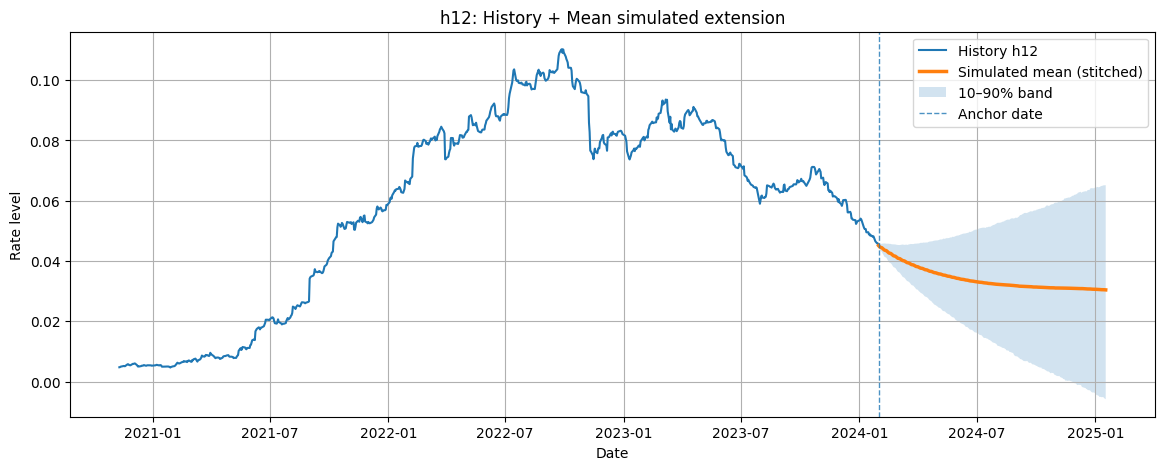

In [ ]:
# [38] Simulate ALL PCA factors conditionally, reconstruct ΔF, reconstruct LEVELS, then stitch plot
def simulate_all_factors_conditional(n_steps=252, n_sims=5000, seed=42):
    rng_master = np.random.default_rng(seed)
    factor_names = list(pca["Z"].columns)
    r = len(factor_names)

    Z_sim = np.zeros((n_sims, n_steps, r))
    for s in range(n_sims):
        base = int(rng_master.integers(0, 2**31-1))
        for k, cname in enumerate(factor_names):
            Z_sim[s, :, k] = simulate_factor_conditional(cname, n_steps=n_steps, seed=base + 1000*k)
    return Z_sim

Z_sim_cond = simulate_all_factors_conditional(n_steps=252, n_sims=5000, seed=RNG_SEED)

dF_sim_cond = reconstruct_dF_from_factors(pca, Z_sim_cond, seed=RNG_SEED)
cols, Fpaths_cond = reconstruct_levels(fwds_horizon, dF_sim_cond, anchor_date=Y.index[-1])

out = stitch_history_with_mean_sim_level(
    fwds_horizon=fwds_horizon,
    sim_dF=dF_sim_cond,
    cols_order=pca["cols"],
    col_name="h12",
    anchor_date=Y.index[-1],
    freq="B",
    bands=(0.10, 0.90),
    hist_window=800
)
